In [8]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import scipy as sp
from scipy import signal 

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [9]:
SYNCHMEASURES = {
                    'Avalanch': "Avalanche Event \nSynchronization", 
                    'DistCor': "Distance Correlation",
                    'Kuramoto': "Kuramoto Parameter", 
                    'GlobalSync': "Global Synchronization", 
                    'SVD': "SVD-based Synchronization \nMeasure",
                    'PLV': "Phase Locked Value\n"
}

In [10]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_02/synchron"
os.makedirs(figureroot, exist_ok=True)

In [11]:
load_dir = "../system_02/results/synchron/"
load_str = datetime.datetime(2024, 4, 12)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, 'results*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 25


In [12]:
# Sorting the files

iVals = {}
kVals = {}

for path in file_paths:
    baseName = os.path.basename(path).split('mV.pkl')[0]
    I = float(baseName.split('_')[-1])
    K = float(baseName.split('_')[2])

    if I not in iVals.keys():
        iVals[I] = []
        kVals[I] = []

    iVals[I].append(path)
    kVals[I].append(K)

for I, kVals_arr in kVals.items():
    kVals_arr = np.array(kVals_arr)
    kSort = np.argsort(kVals_arr) 
    iVals[I] = np.array(iVals[I])[kSort]

In [126]:
def PlotResponses(Imod, measure, mSymbol, xArr, yArr, kArr, freqBand=None, saveroot=figureroot):
    LOWSIGE = np.zeros((4, len(kArr)))
    HIGHSIGE = np.zeros((4, len(kArr)))

    for nI, I in enumerate(Imod):
        iPaths = iVals[I]
        I = I - params['i_e2']

        fig, axes = plt.subplots(1, len(kArr) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1,1.2]})
        nCol = 0
        for nf, path in enumerate(iPaths):
            baseName = os.path.basename(path).split('mV.pkl')[0]
            K = float(baseName.split('_')[2])

            synchData = pickle.load(open(path, 'rb'))
            dataArray = synchData[measure]
            dataArray[np.isnan(dataArray)] = 0.0 

            if measure == "Kuramoto":
                dataArray = dataArray / np.max(dataArray)
            
            if measure == "DistCor" or measure == "SVD" or measure == "GlobSynch":
                dataArray[dataArray < 0.09] = 0
            
            if I == 31.25:
                LOWSIGE[0, nf] = dataArray[0, 0]
                LOWSIGE[1, nf] = dataArray[0, 1]
                LOWSIGE[2, nf] = dataArray[0, 2]
                LOWSIGE[3, nf] = dataArray[0, -1]

                HIGHSIGE[0, nf] = dataArray[2, 0]
                HIGHSIGE[1, nf] = dataArray[2, 1]
                HIGHSIGE[2, nf] = dataArray[2, 2]
                HIGHSIGE[3, nf] = dataArray[2, -1]
                    
            if K == 0.0:
                continue

            pcor = axes[nCol].pcolormesh(xArr, yArr, dataArray, vmin=0, vmax=1, cmap='Blues')
            axes[nCol].set_ylim(min(yArr), max(yArr))
            axes[nCol].set_yticks(yArr)
            axes[nCol].set_xlim(min(xArr), max(xArr))
            axes[nCol].set_xticks(xArr[::2])
            
            if nCol == 0:
                axes[nCol].set_ylabel(f"Excitatory \nheterogeneity " + r"$(\sigma_e)$", fontsize=16)
            nCol += 1
                
        cbar = fig.colorbar(pcor, ax=axes[len(kArr) - 2])
        axes[len(kArr) - 2].text(16.5, 17.3, mSymbol, fontsize=18)
        fig.supxlabel(f"Inhibitory heterogeneity " + r"$(\sigma_i)$", fontsize=16)
        plt.tight_layout()

        if freqBand:
            plt.savefig(os.path.join(saveroot, f"{measure}_Imod_{I:3f}mV_Responsemaps_{freqBand}.jpg"), dpi=300, bbox_inches='tight')
        else:
            plt.savefig(os.path.join(saveroot, f"{measure}_Imod_{I:3f}mV_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
        plt.show()


    PLOT_SIGI = [xArr[0], xArr[1], xArr[2], xArr[-1]]
    PLOT_COLORS = ['b', 'r', 'g', 'purple']

    plt.figure(figsize=(10, 2))
    for i in range(4):
        if PLOT_SIGI[i] == yArr[0]:
            plt.plot(kArr, LOWSIGE[i, :], '.--', color='k', label=r"$\sigma_{\rm i}=$"+f"{PLOT_SIGI[i]:.2f}", linewidth=1.4)
        else:
            plt.plot(kArr, LOWSIGE[i, :], '.-', color=PLOT_COLORS[i], label=r"$\sigma_{\rm i}=$"+f"{PLOT_SIGI[i]:.2f}", linewidth=2)
    plt.plot(kArr, LOWSIGE[0, :], '.--', color='k', linewidth=1.4)
    plt.xticks(kArr); plt.ylim(-0.05, 1.05)
    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)

    plt.title(r"$\sigma_{\rm e} = $" + f"{yArr[0]:.2f}", fontsize=20)
    plt.ylabel(mSymbol, rotation=0, labelpad=25)
    plt.xlabel(r"Synaptic coupling gain $(K_{\rm glob})$", labelpad=15)
    plt.legend(loc='lower center', ncols=4, bbox_to_anchor=(0.45, -1), frameon=False)

    if freqBand:
        plt.savefig(os.path.join(saveroot, f"{measure}_Imod_{I:3f}mV_K_LOWSIGI_{freqBand}.jpg"), dpi=300, bbox_inches='tight')
    else:
        plt.savefig(os.path.join(saveroot, f"{measure}_Imod_{I:3f}mV_K_LOWSIGI.jpg"), dpi=300, bbox_inches='tight')
    plt.show()

    PLOT_SIGI = [xArr[0], xArr[1], xArr[2], xArr[-1]]
    PLOT_COLORS = ['b', 'r', 'g', 'purple']
    
    plt.figure(figsize=(10, 2))
    for i in range(4):
        if PLOT_SIGI[i] == yArr[2]:
            plt.plot(kArr, HIGHSIGE[i, :], '.--', color='k', label=r"$\sigma_{\rm i}=$"+f"{PLOT_SIGI[i]:.2f}", linewidth=1.4)
        else:
            plt.plot(kArr, HIGHSIGE[i, :], '.-', color=PLOT_COLORS[i], label=r"$\sigma_{\rm i}=$"+f"{PLOT_SIGI[i]:.2f}", linewidth=2)
    
    plt.plot(kArr, HIGHSIGE[2, :], '.--', color='k', linewidth=1.4)
    plt.xticks(kArr); plt.ylim(-0.05, 1.05)
    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)

    plt.title(r"$\sigma_{\rm e} = $" + f"{yArr[2]:.2f}", fontsize=20)
    plt.ylabel(mSymbol, rotation=0, labelpad=25)
    plt.xlabel(r"Synaptic coupling gain $(K_{\rm glob})$", labelpad=15)
    plt.legend(loc='lower center', ncols=4, bbox_to_anchor=(0.45, -1), frameon=False)

    if freqBand:
        plt.savefig(os.path.join(saveroot, f"{measure}_Imod_{I:3f}mV_K_HIGHSIGI_{freqBand}.jpg"), dpi=300, bbox_inches='tight')
    else:
        plt.savefig(os.path.join(saveroot, f"{measure}_Imod_{I:3f}mV_K_HIGHSIGI.jpg"), dpi=300, bbox_inches='tight')
    plt.show()
    
    return

In [127]:
iPert = iVals

sige_min = 2.5; sige_max = 16.5; sige_steps = 20
eval_sigmae = sige_min + np.arange(0, sige_steps) / (sige_steps - 1) * (sige_max - sige_min)
eval_sigmae = np.concatenate((eval_sigmae[0:3:3], eval_sigmae[3::4])); sige_steps = len(eval_sigmae)

sigi_min = 2.5; sigi_max = 16.5; sigi_steps = 20
eval_sigmai = sigi_min + np.arange(0, sigi_steps) / (sigi_steps - 1) * (sigi_max - sigi_min)
eval_sigmai = np.concatenate((eval_sigmai[0:3:3], eval_sigmai[3::4])); sige_steps = len(eval_sigmai)


kValArr = sorted(np.array(kVals[0.0]))

In [128]:
eval_sigmae

array([ 2.5       ,  4.71052632,  7.65789474, 10.60526316, 13.55263158,
       16.5       ])

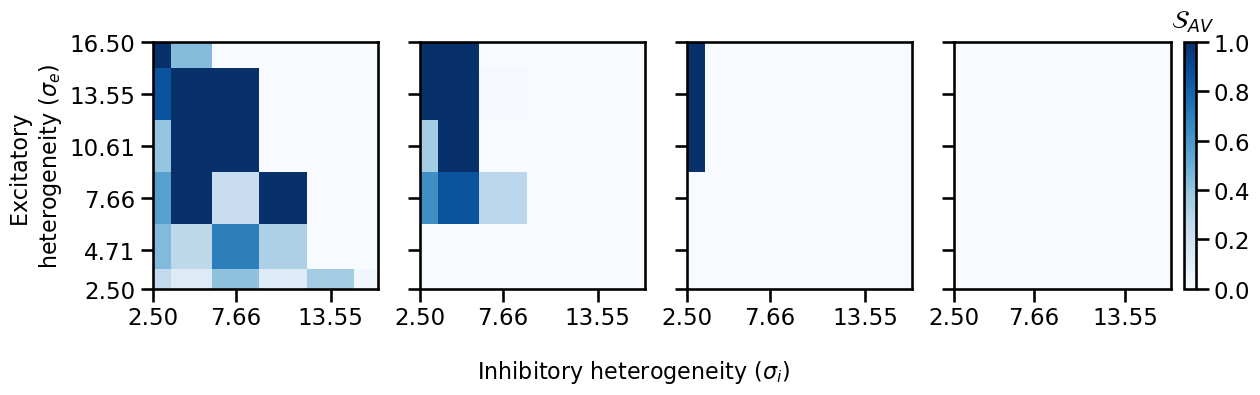

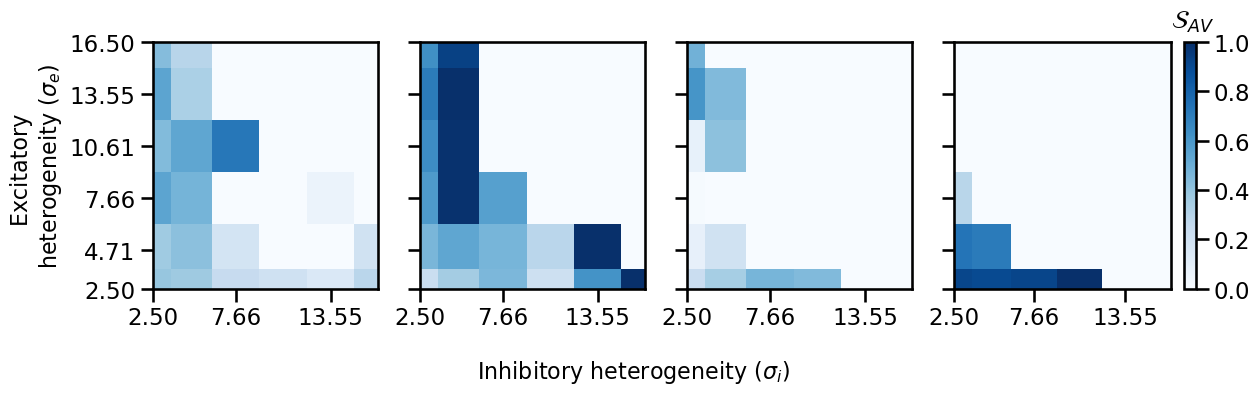

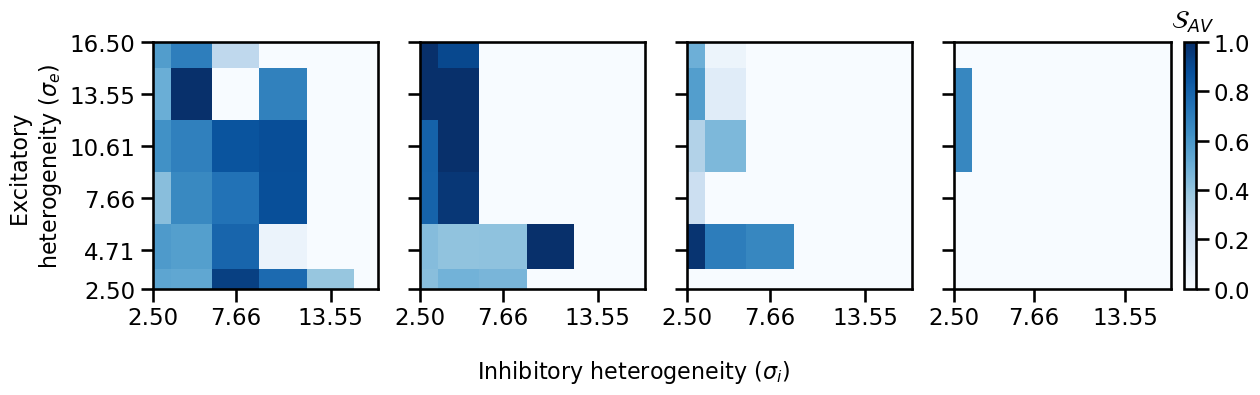

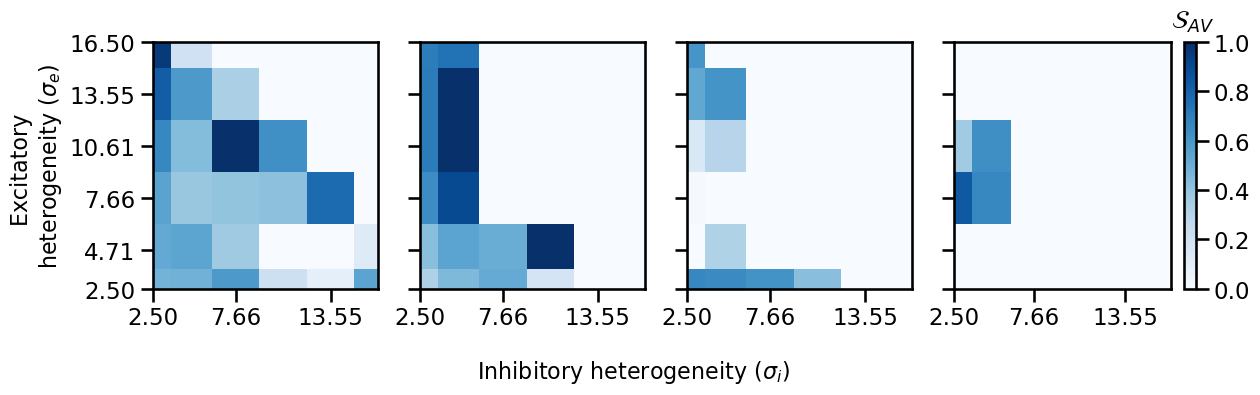

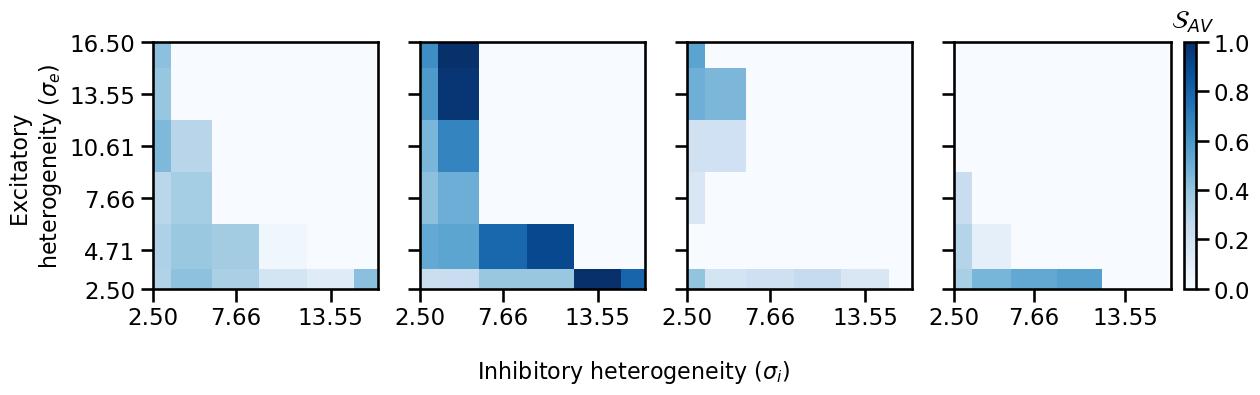

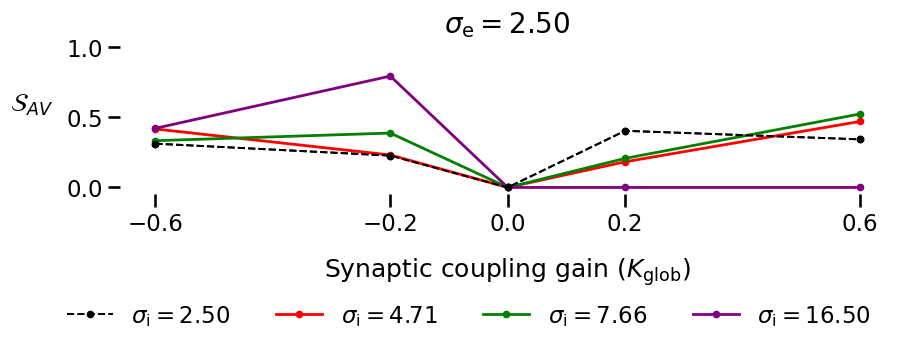

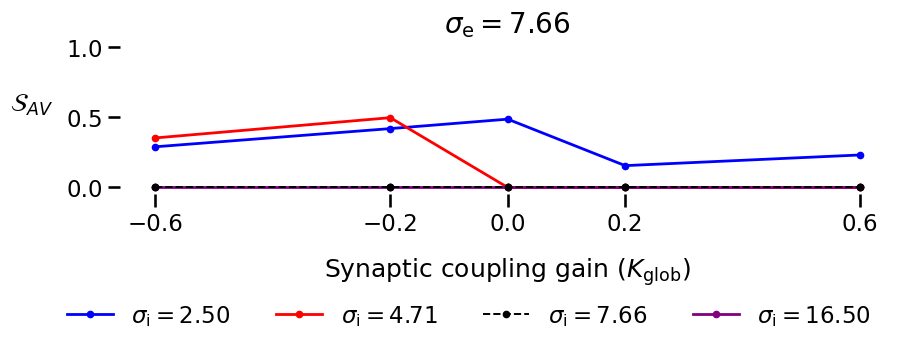

In [129]:
measure = "Avalanch"

PlotResponses(Imod = iPert, measure = measure,  mSymbol = r"$\mathcal{S}_{AV}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, saveroot=figureroot)

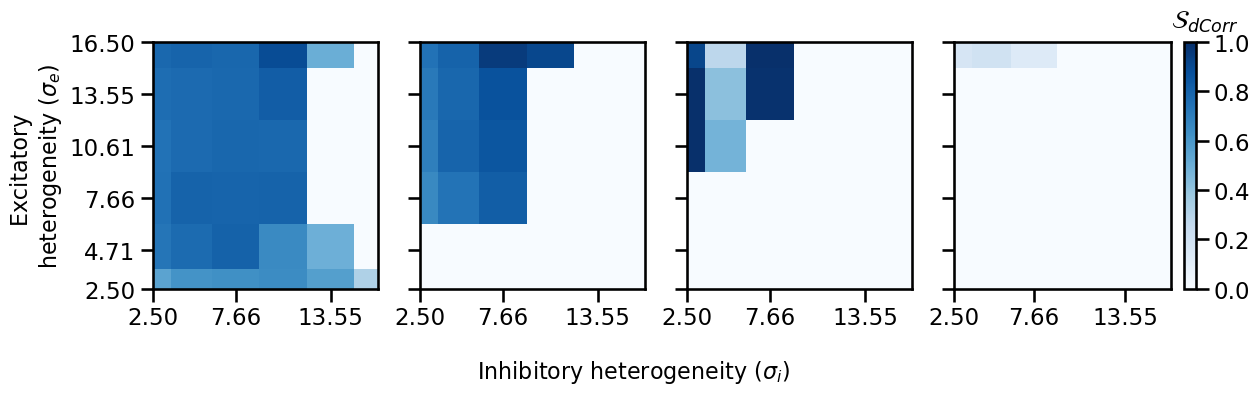

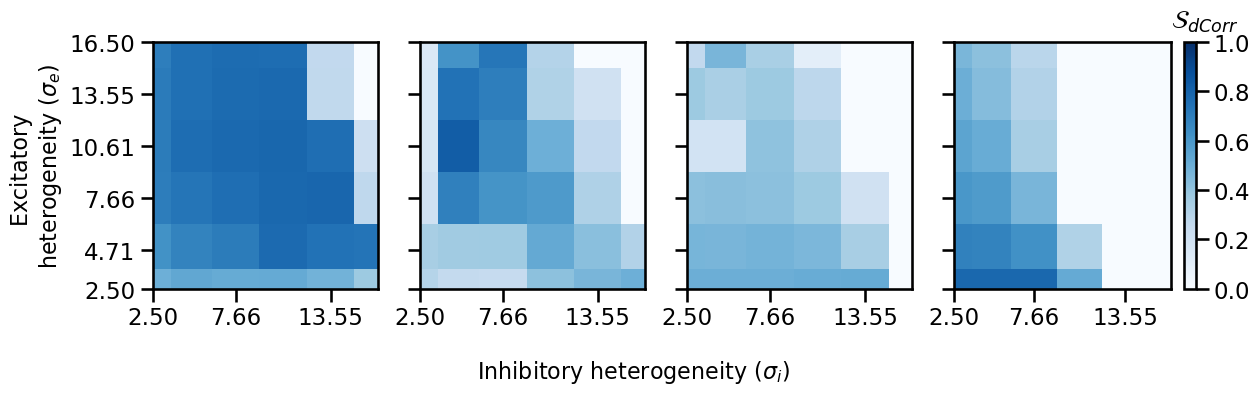

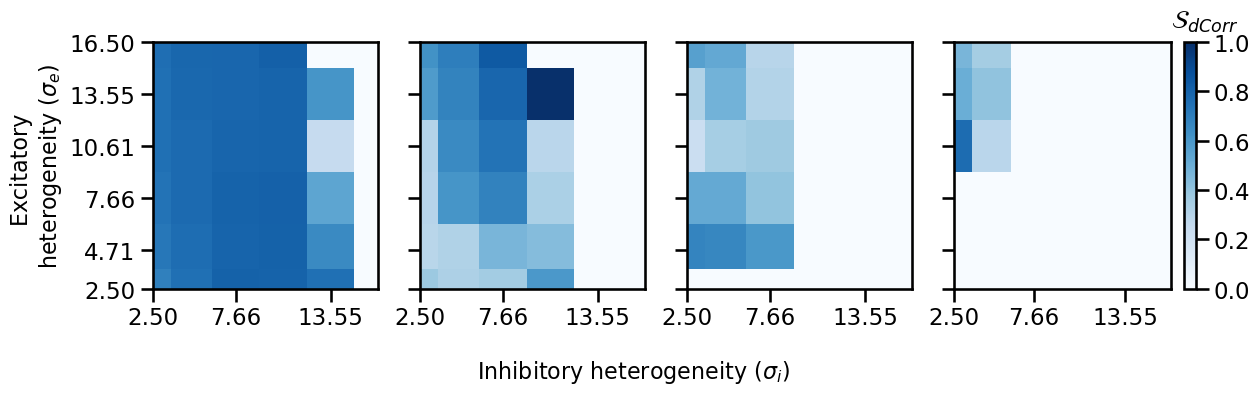

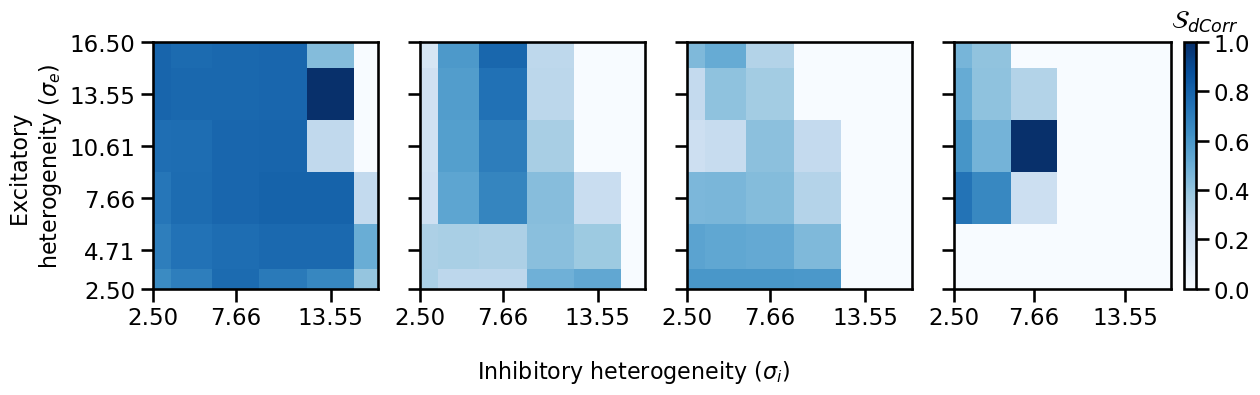

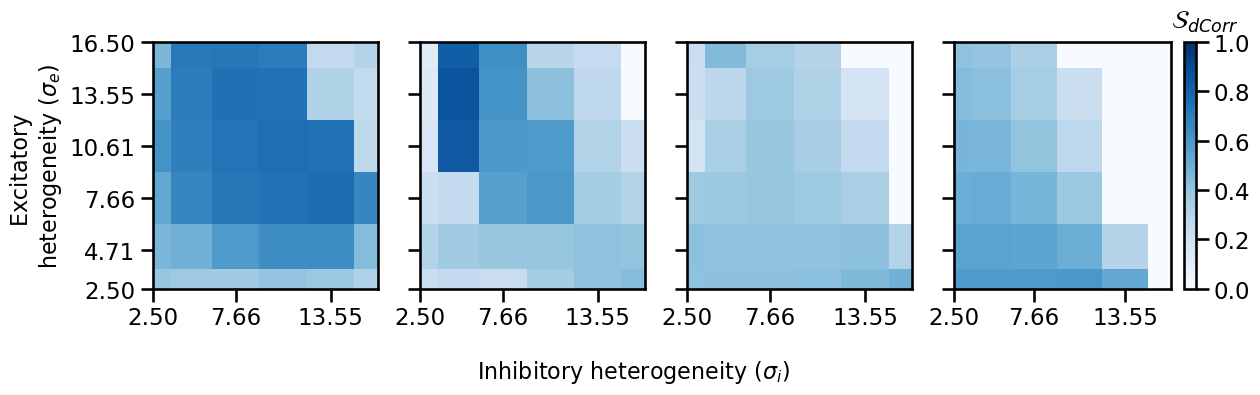

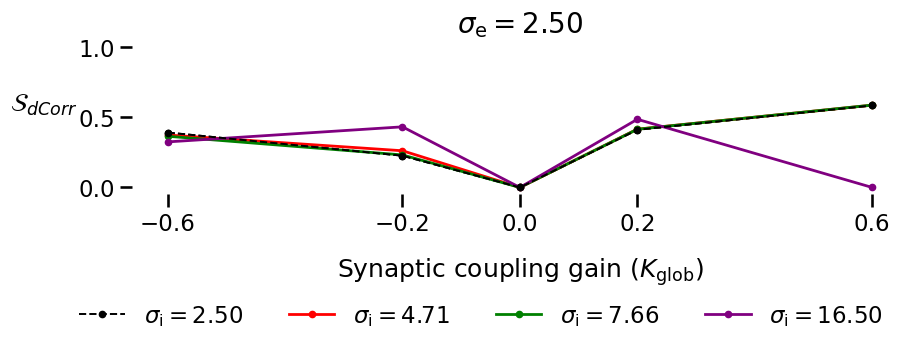

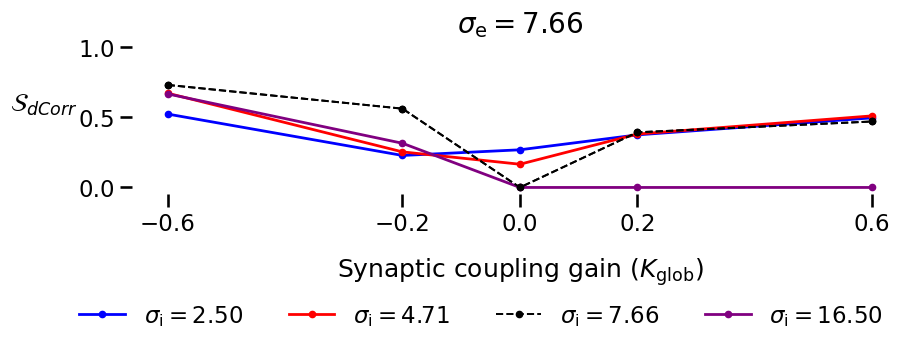

In [130]:
measure = "DistCor"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{dCorr}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, saveroot=figureroot)

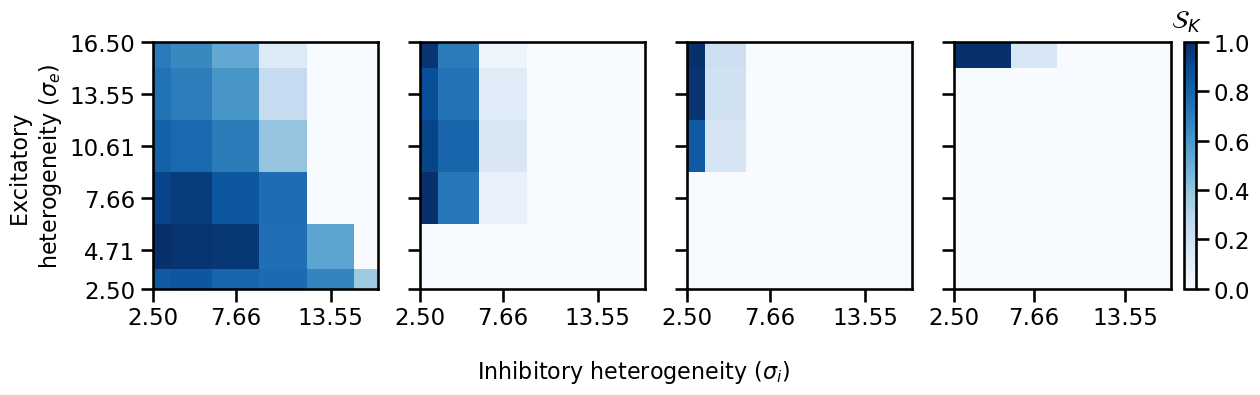

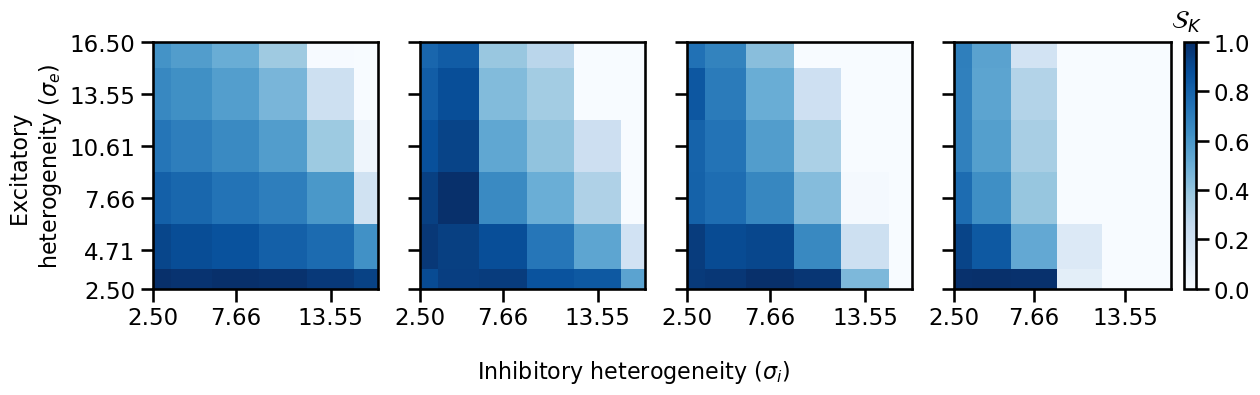

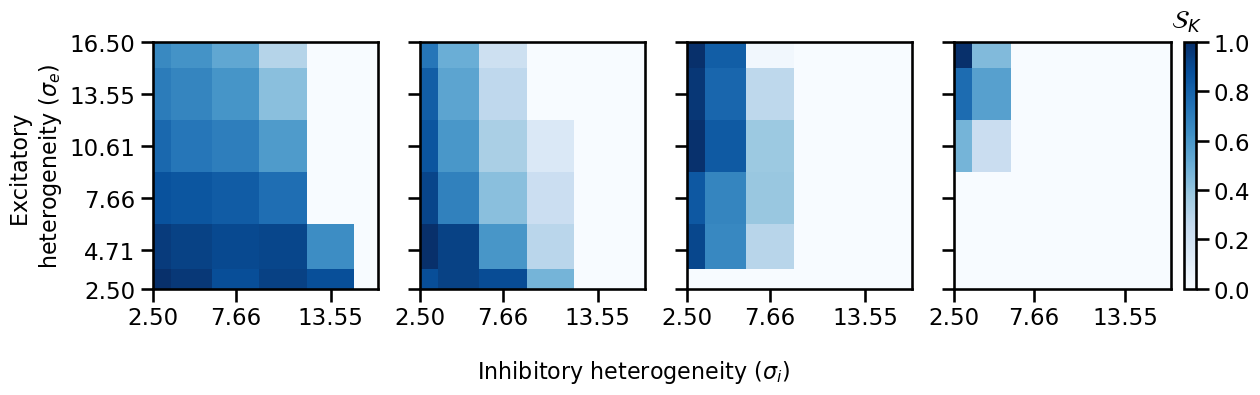

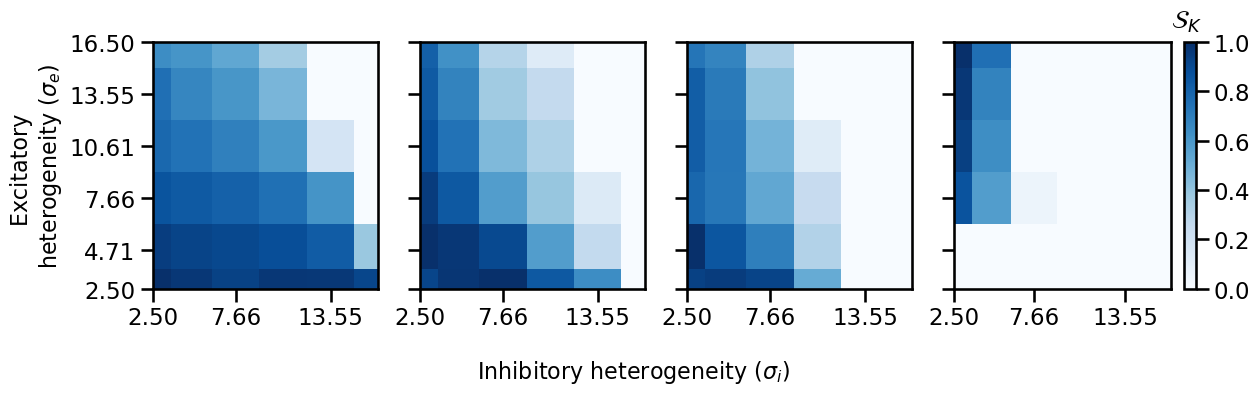

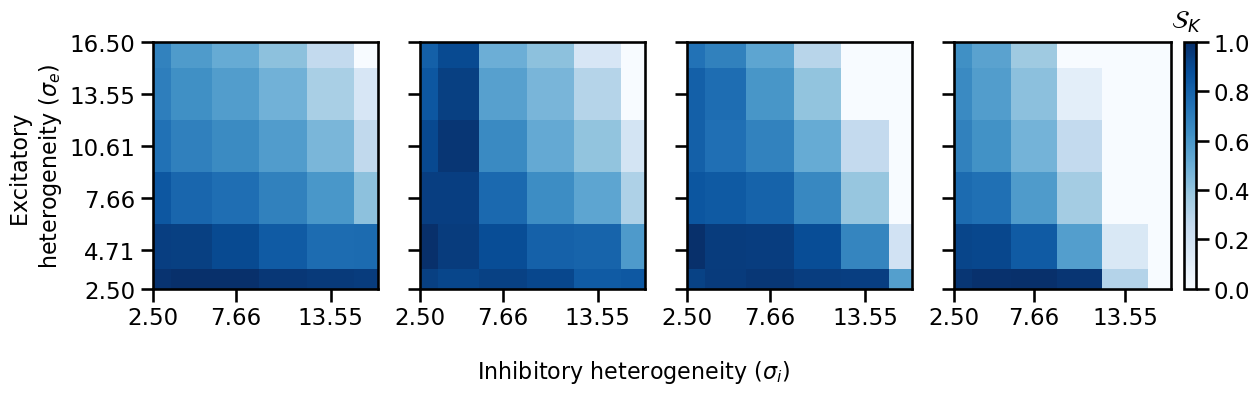

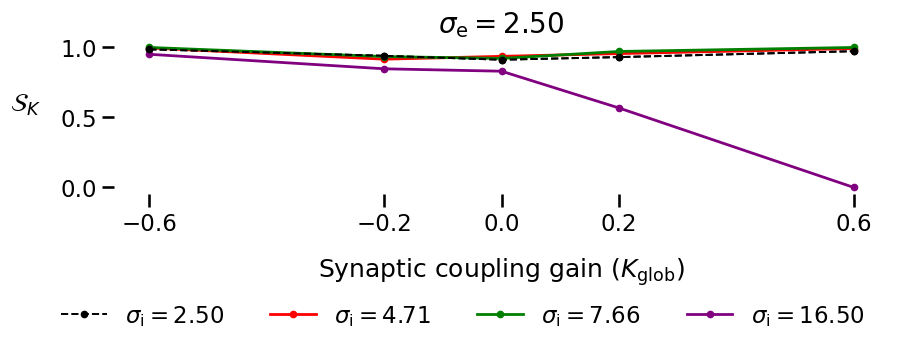

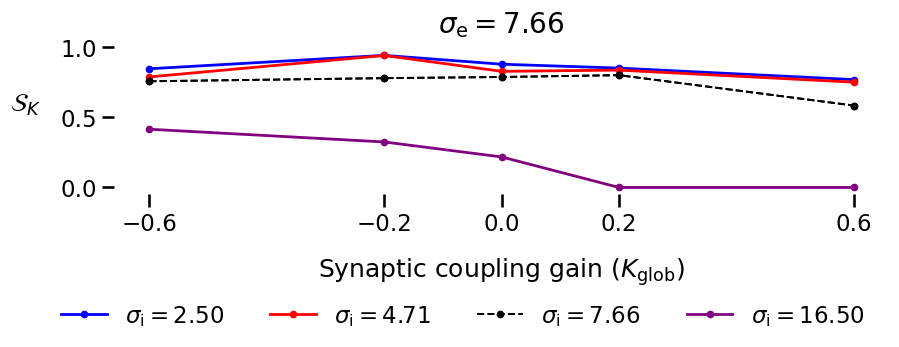

In [131]:
measure = "Kuramoto"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{K}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, saveroot=figureroot)

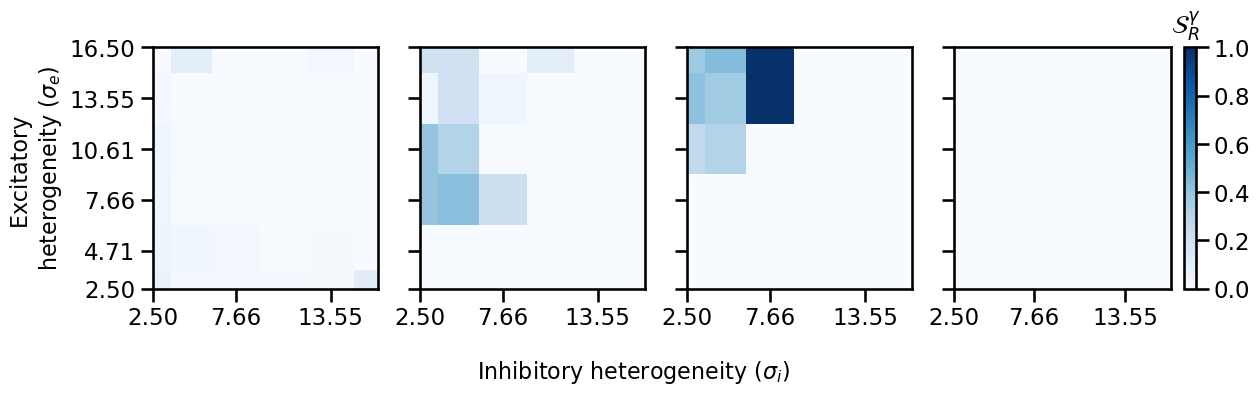

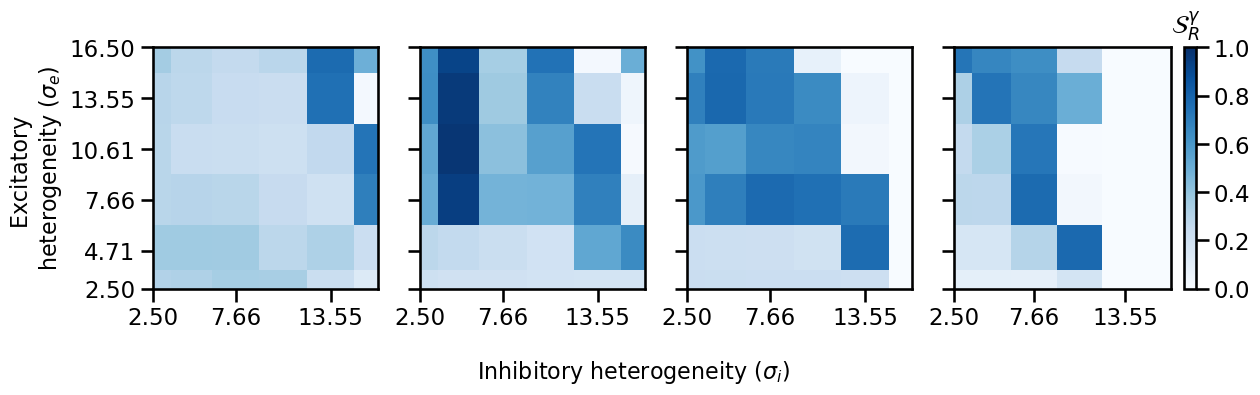

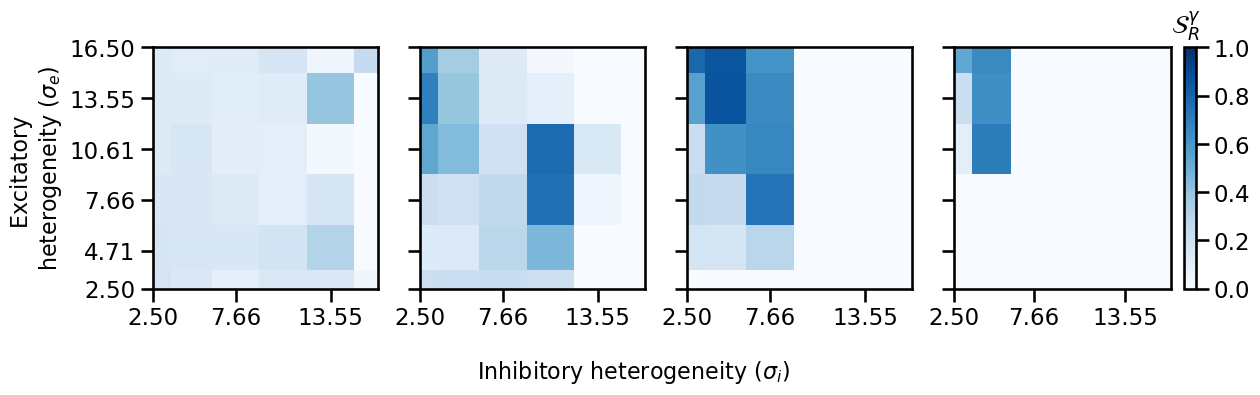

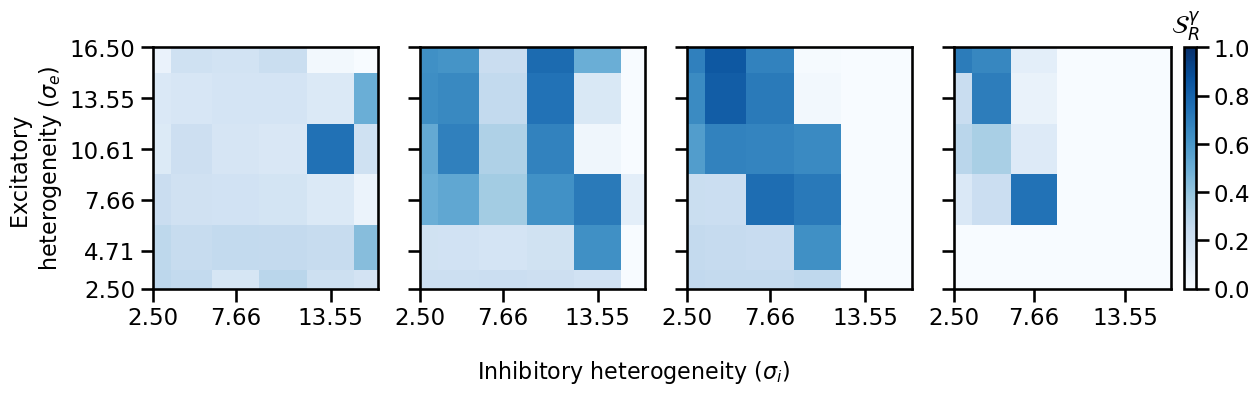

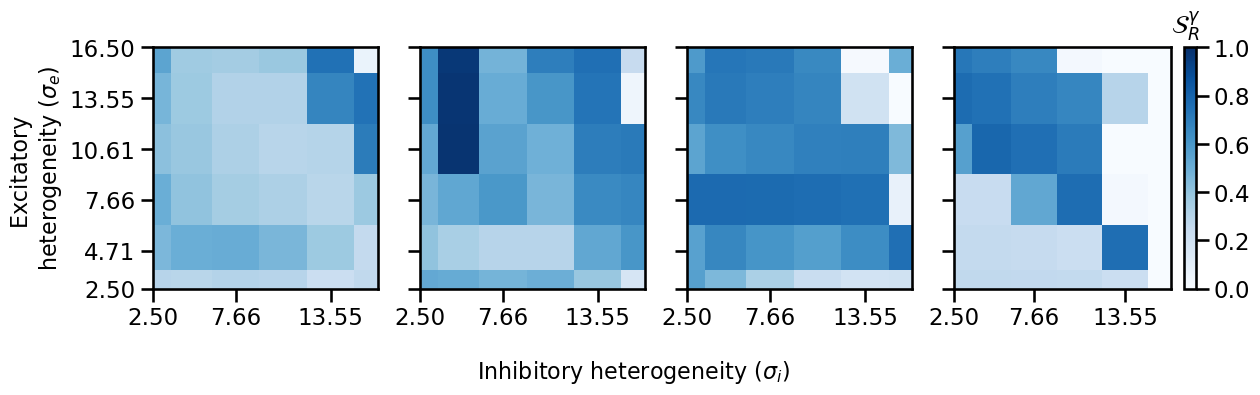

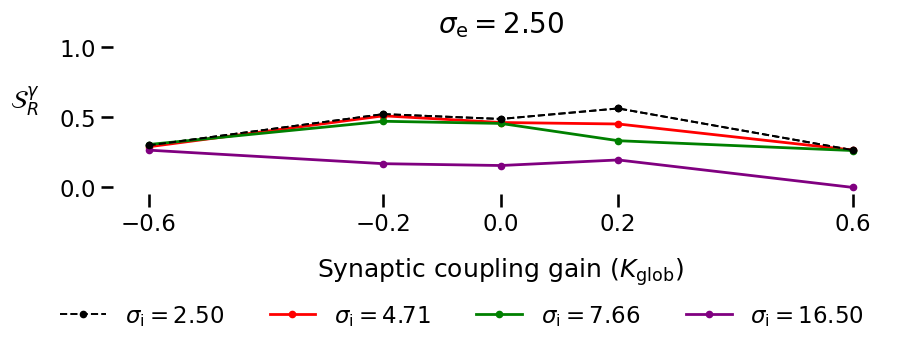

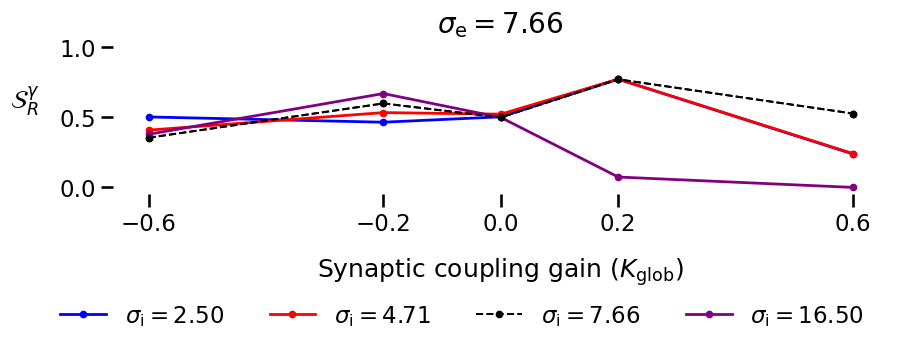

In [132]:
measure = "GlobalSync"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{R}^{\gamma}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="Gamma", saveroot=figureroot)

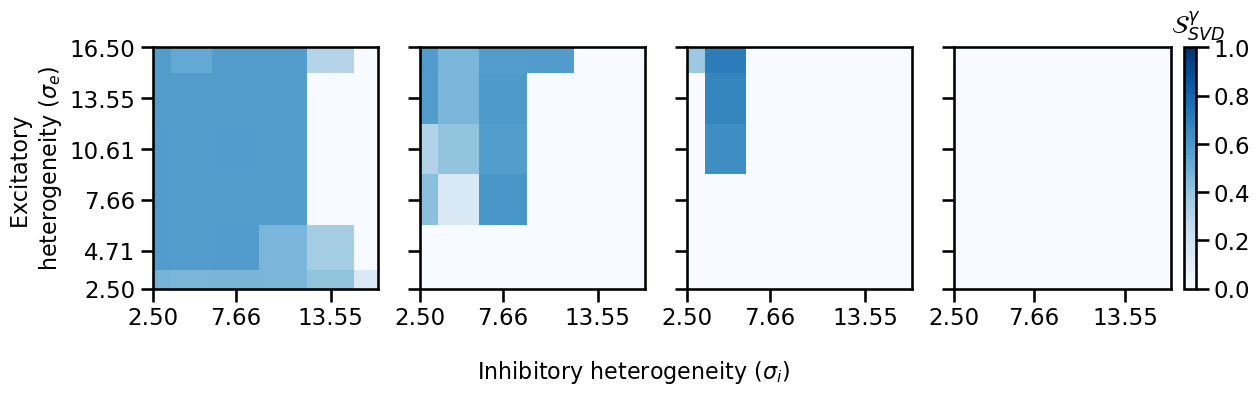

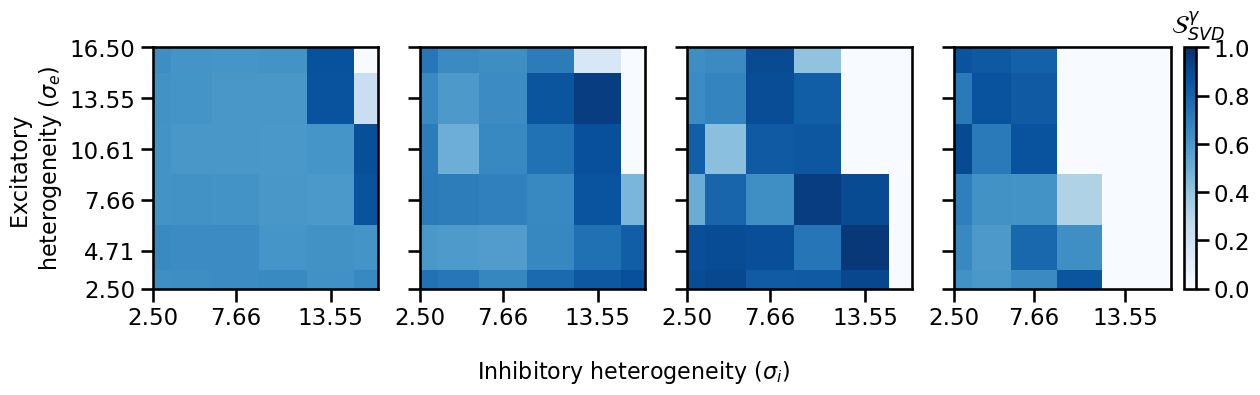

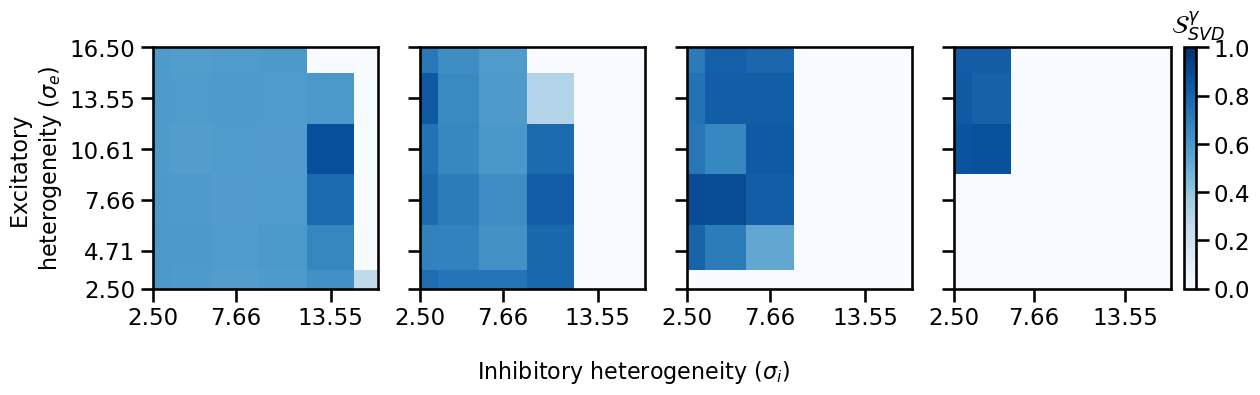

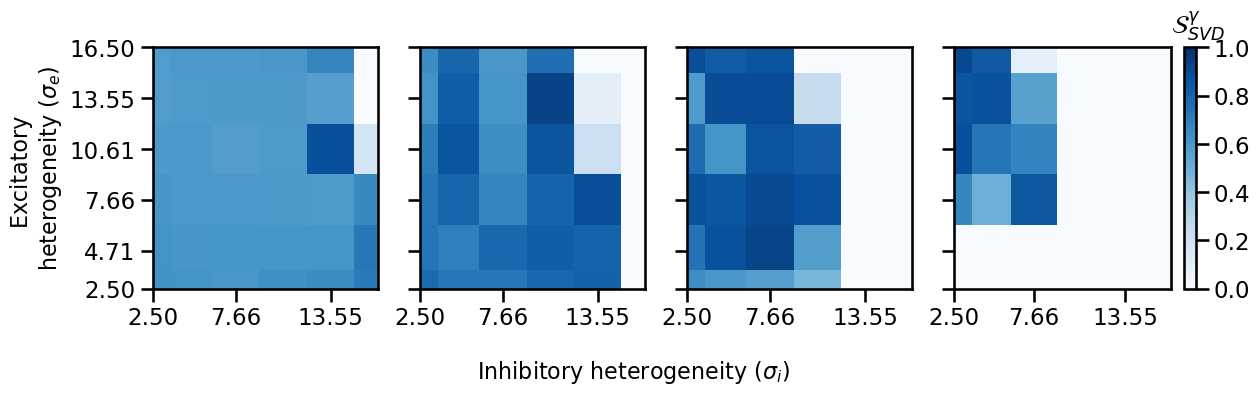

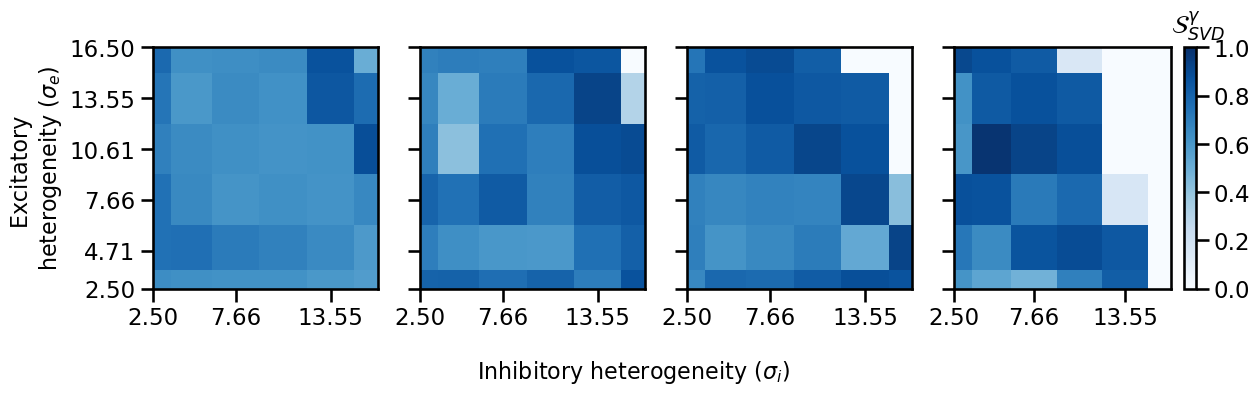

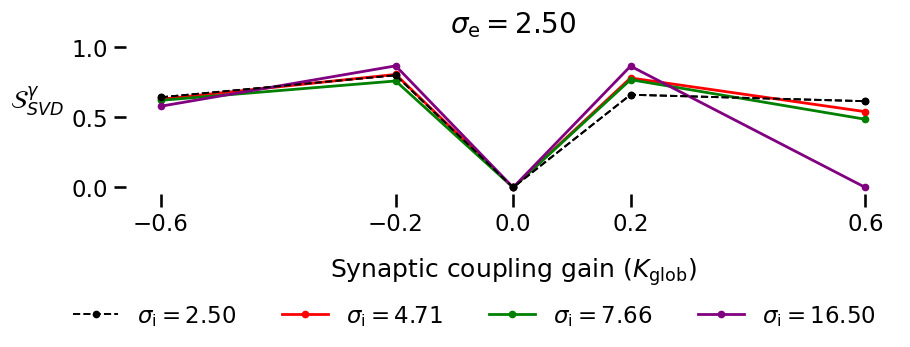

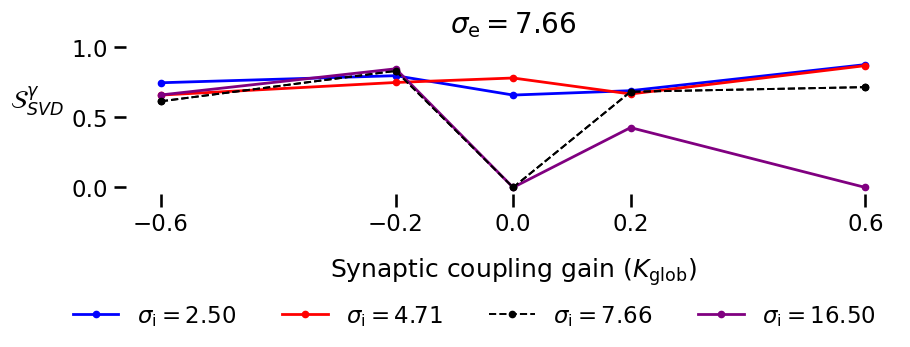

In [133]:
measure = "SVD"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{SVD}^{\gamma}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="Gamma",  saveroot=figureroot)

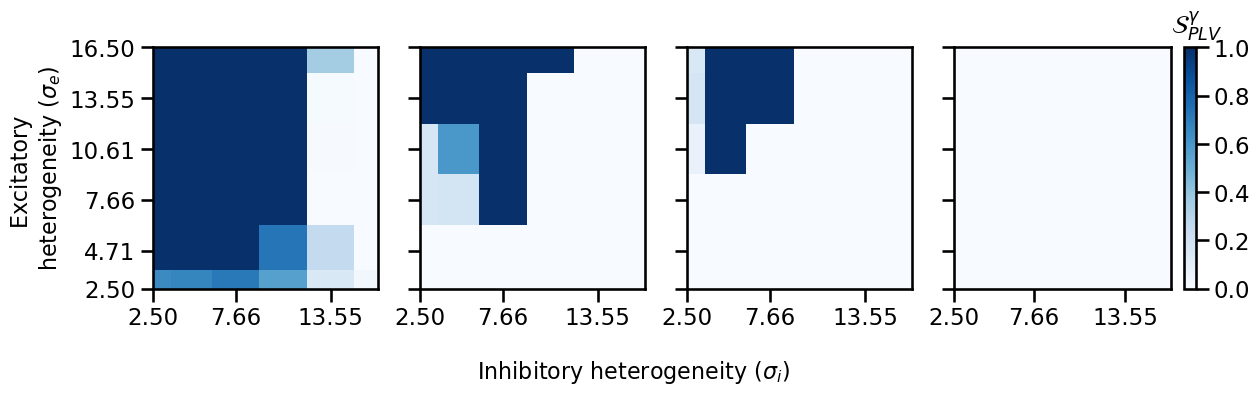

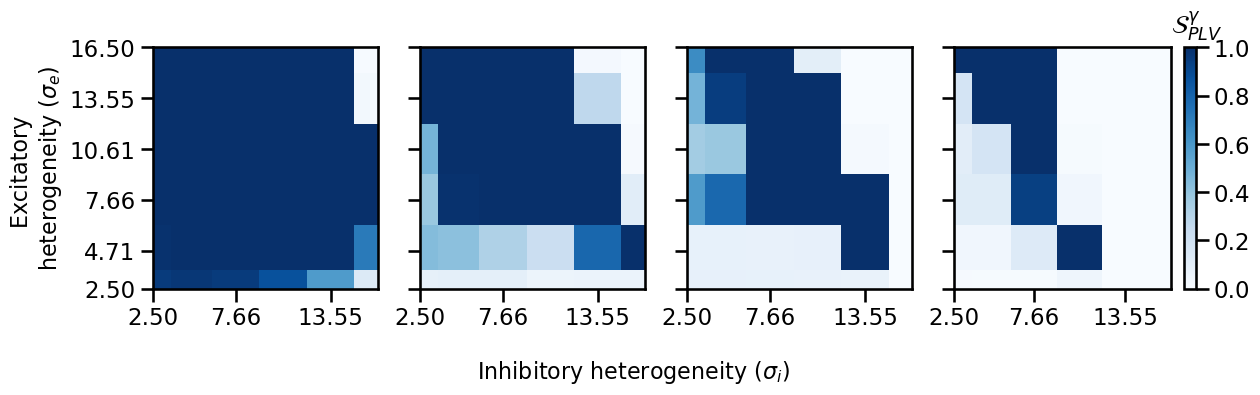

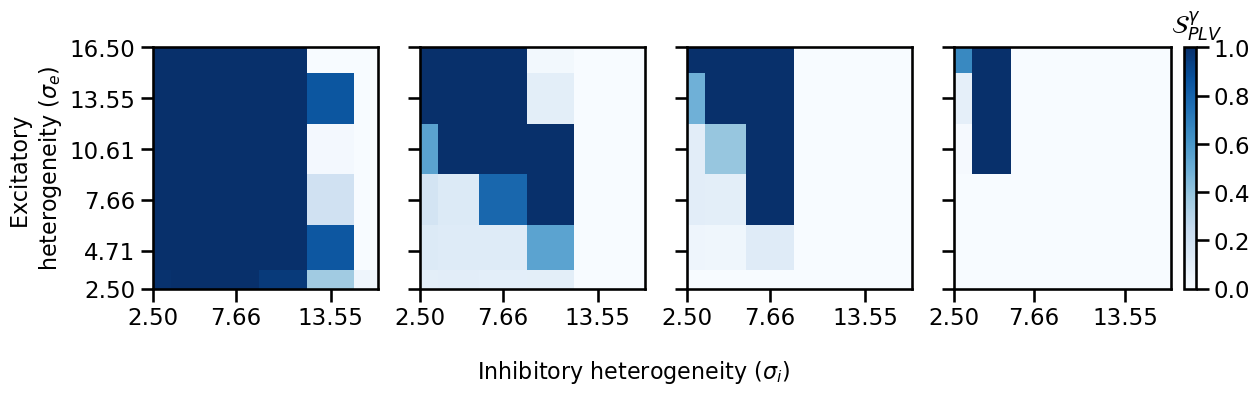

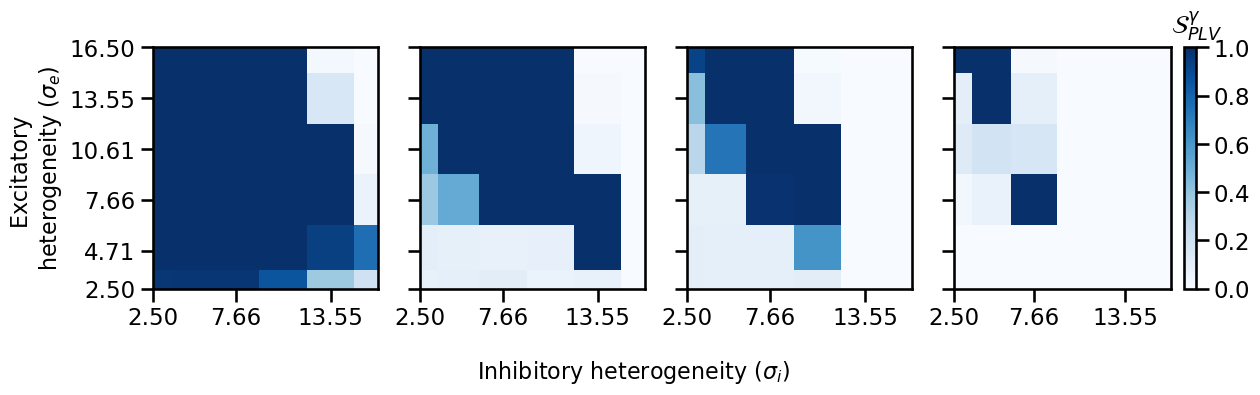

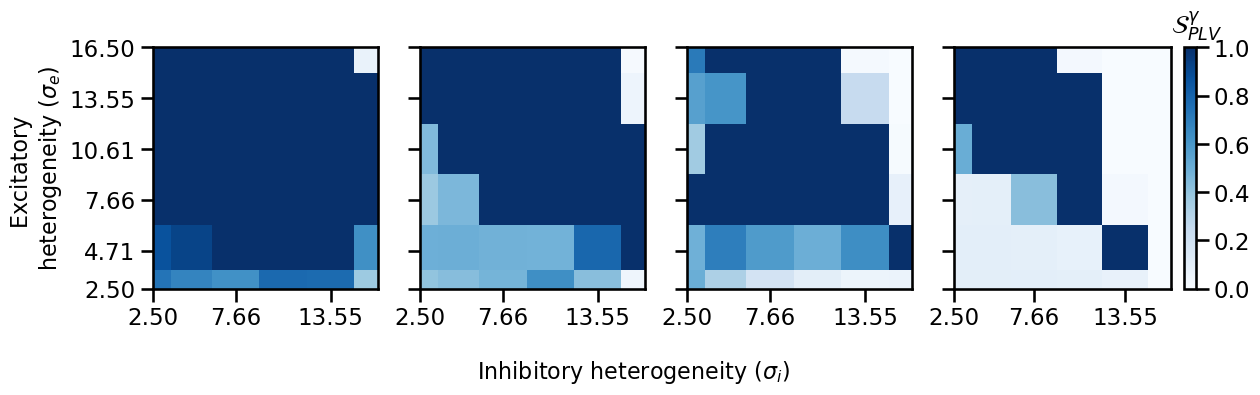

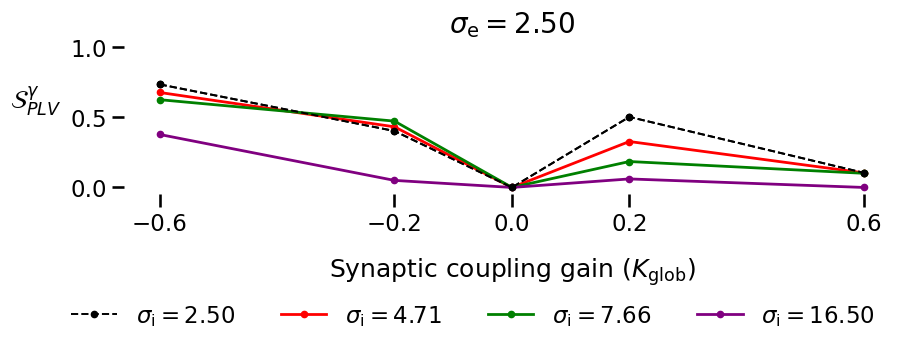

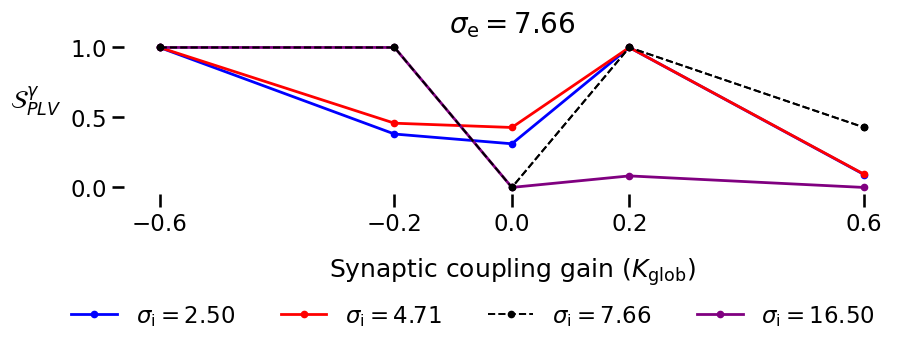

In [134]:
measure = "PLV"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{PLV}^{\gamma}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="Gamma",  saveroot=figureroot)

### Synchronization in LFOs

In [14]:
load_dir = "../system_02/results/synchron/"
load_str = datetime.datetime(2024, 4, 23)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, 'results*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 25


In [15]:
# Sorting the files

iVals = {}
kVals = {}

for path in file_paths:
    baseName = os.path.basename(path).split('mV.pkl')[0]
    I = float(baseName.split('_')[-1])
    K = float(baseName.split('_')[2])

    if I not in iVals.keys():
        iVals[I] = []
        kVals[I] = []

    iVals[I].append(path)
    kVals[I].append(K)

for I, kVals_arr in kVals.items():
    kVals_arr = np.array(kVals_arr)
    kSort = np.argsort(kVals_arr) 
    iVals[I] = np.array(iVals[I])[kSort]

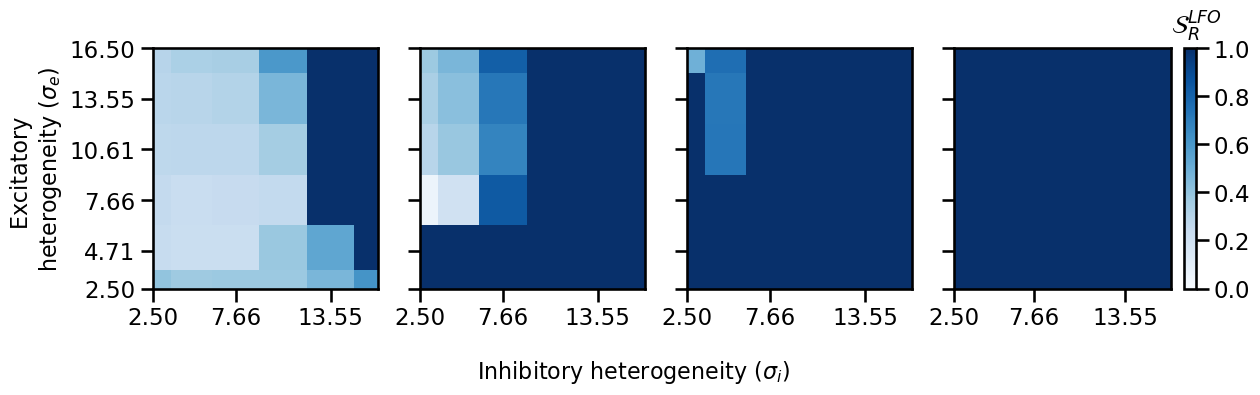

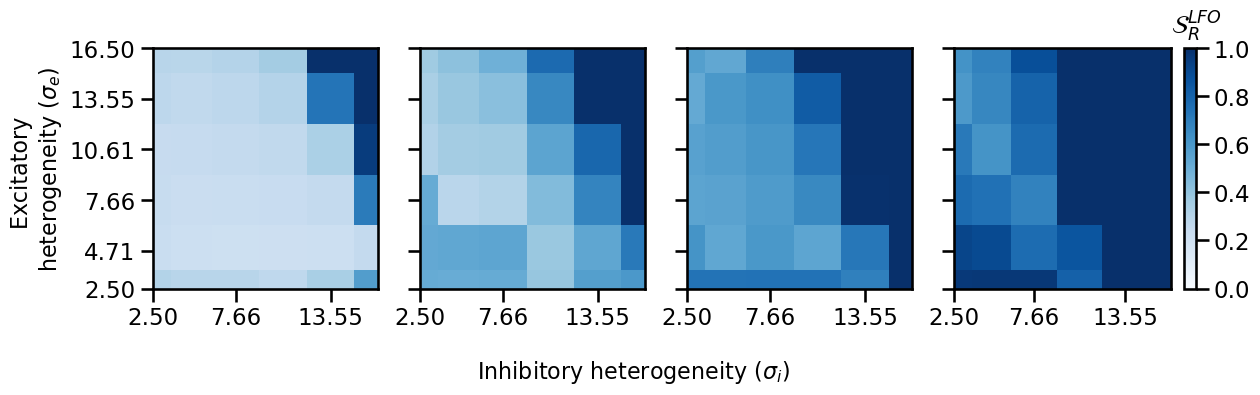

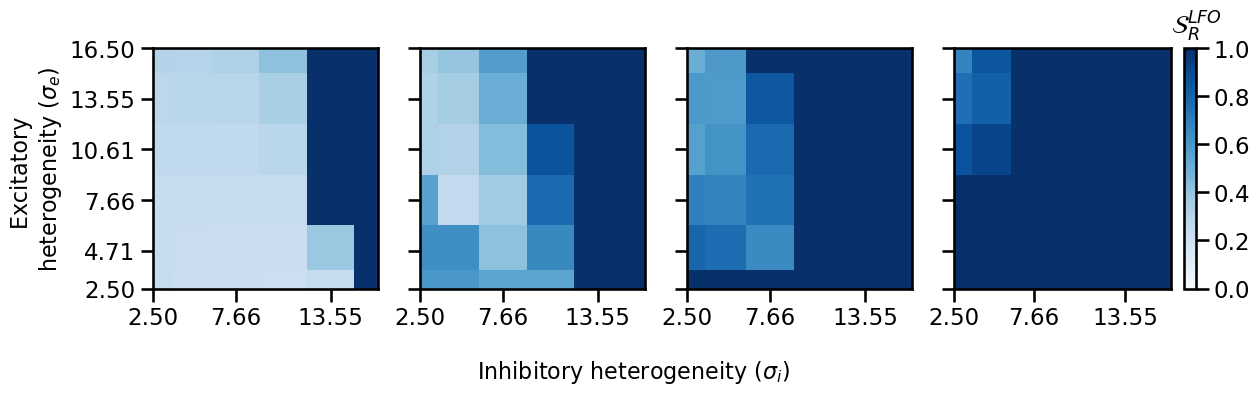

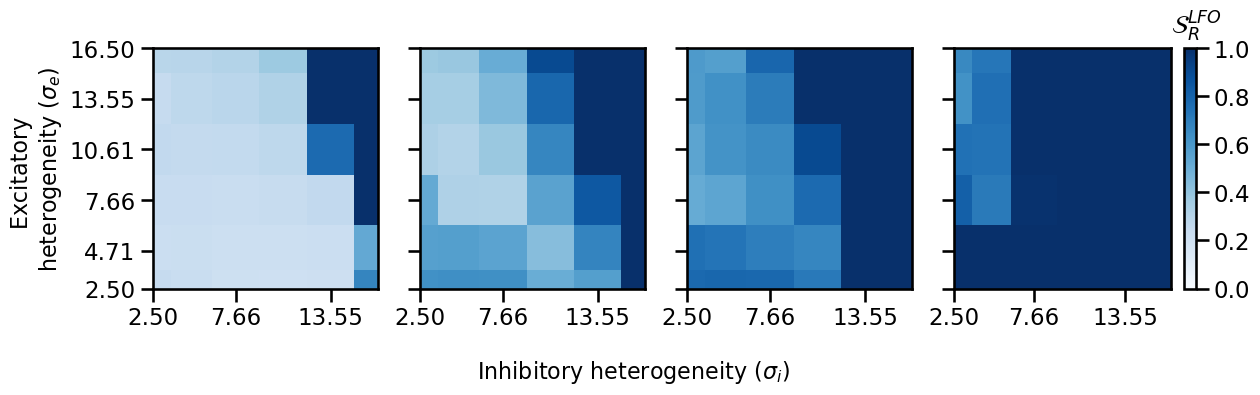

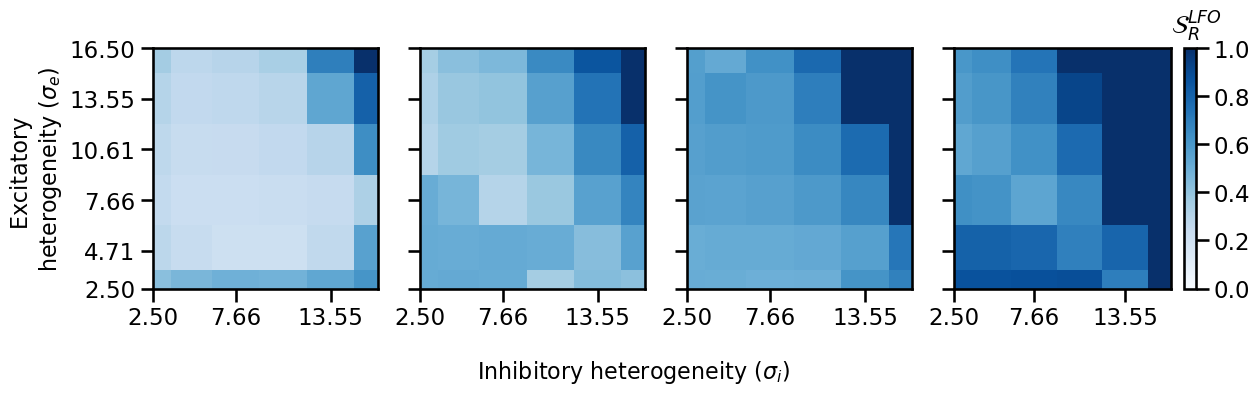

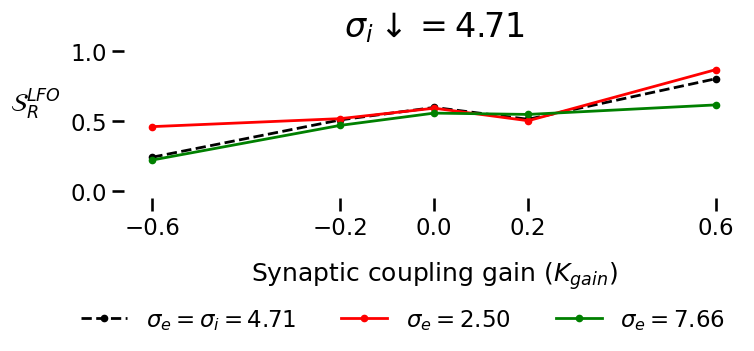

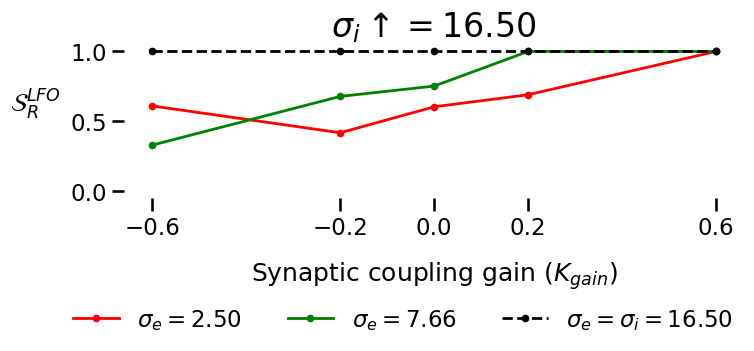

In [16]:
measure = "GlobalSync"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{R}^{LFO}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="LFO",  saveroot=figureroot)

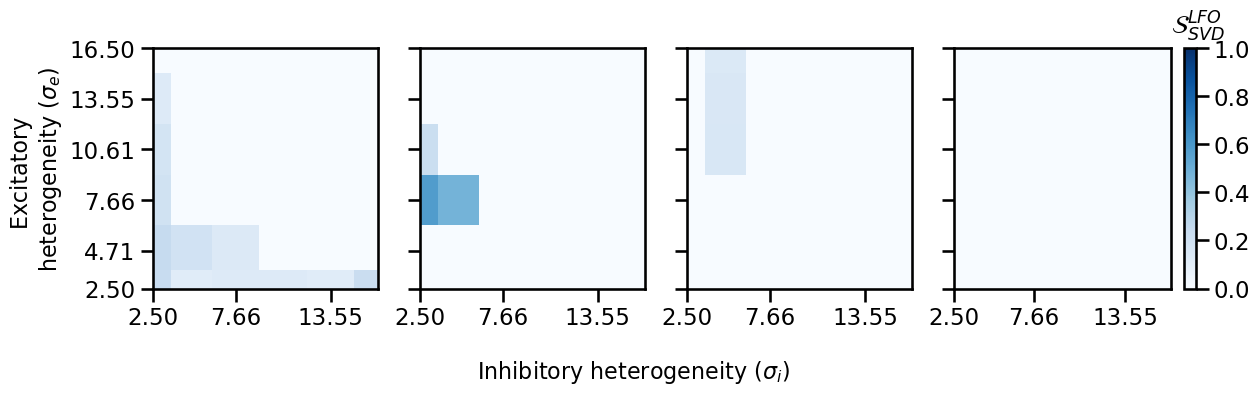

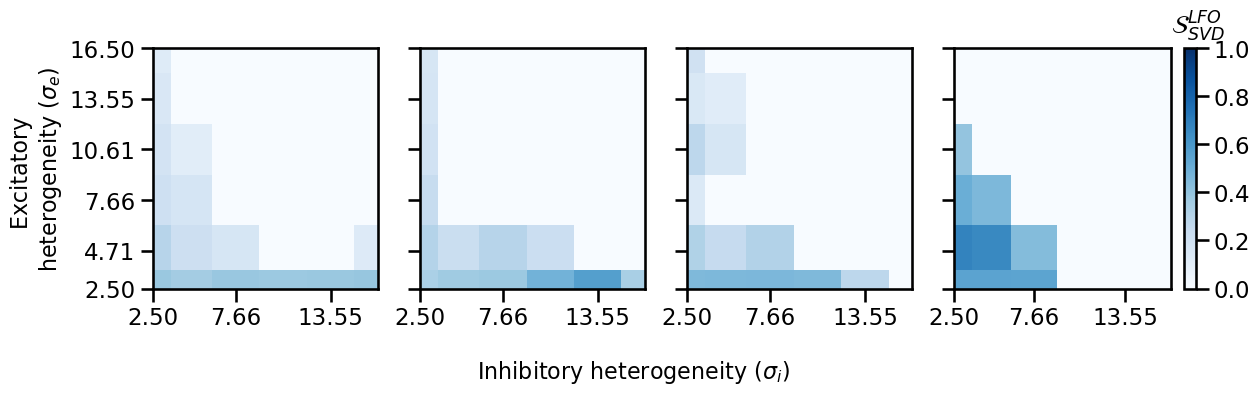

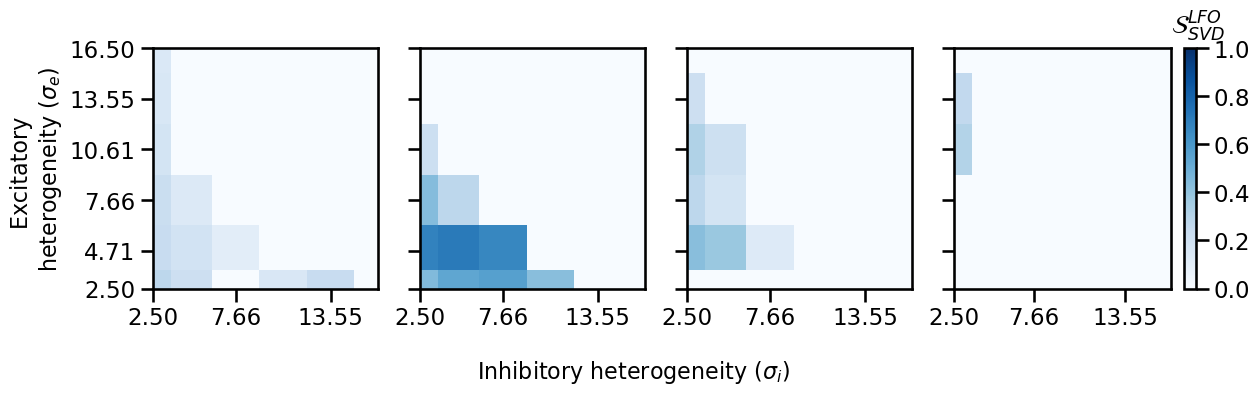

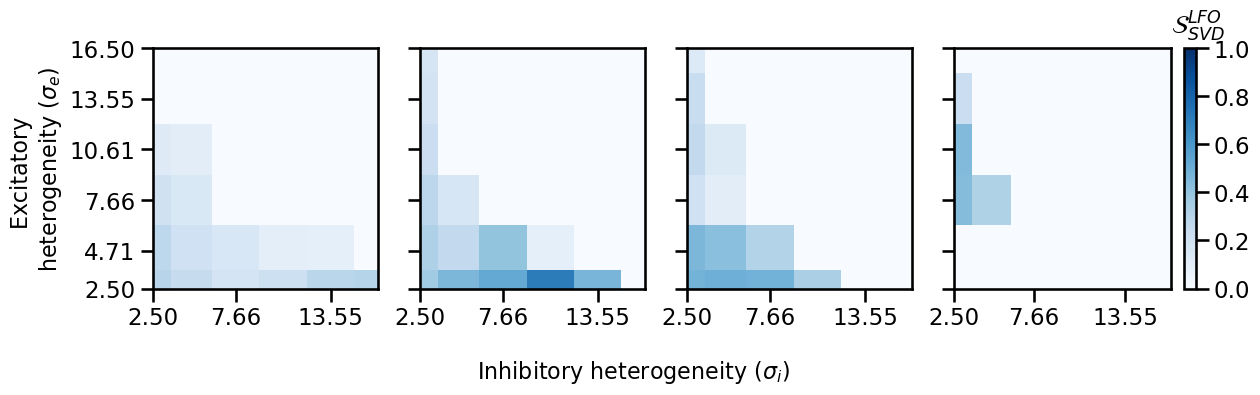

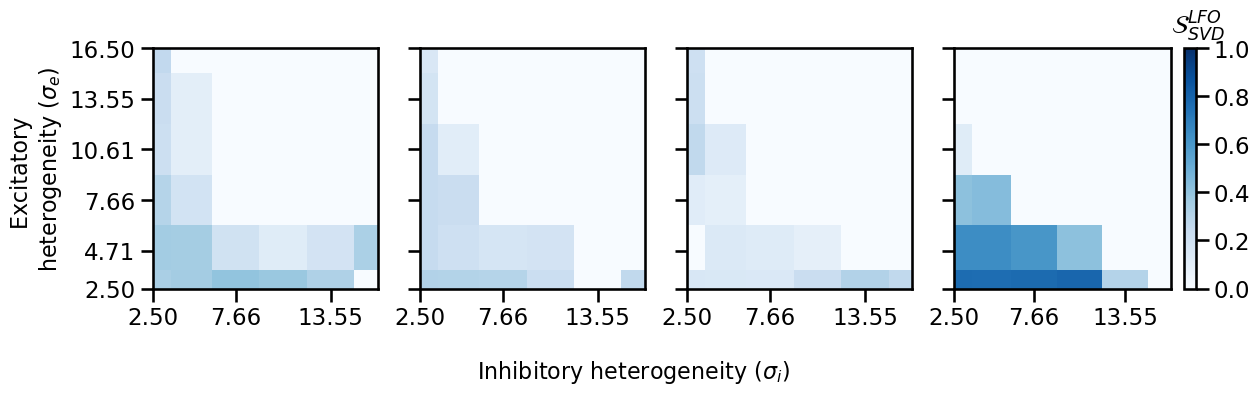

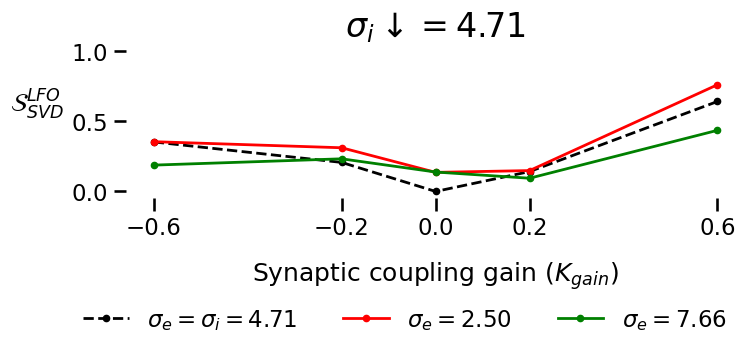

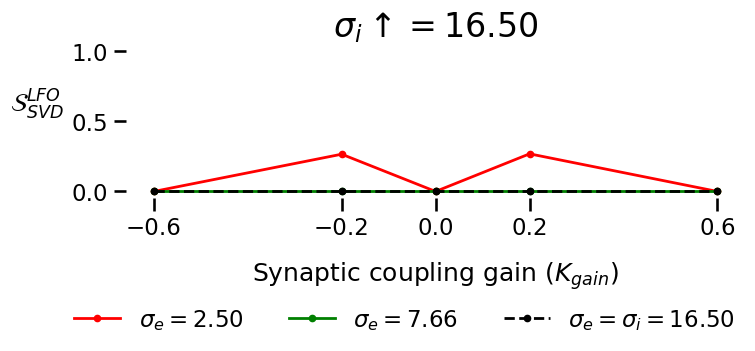

In [17]:
measure = "SVD"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{SVD}^{LFO}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="LFO", saveroot=figureroot)

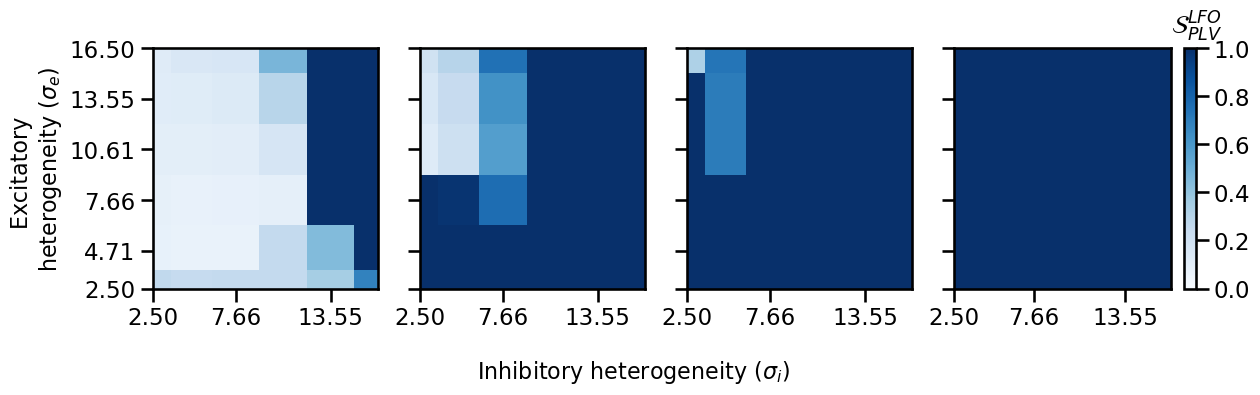

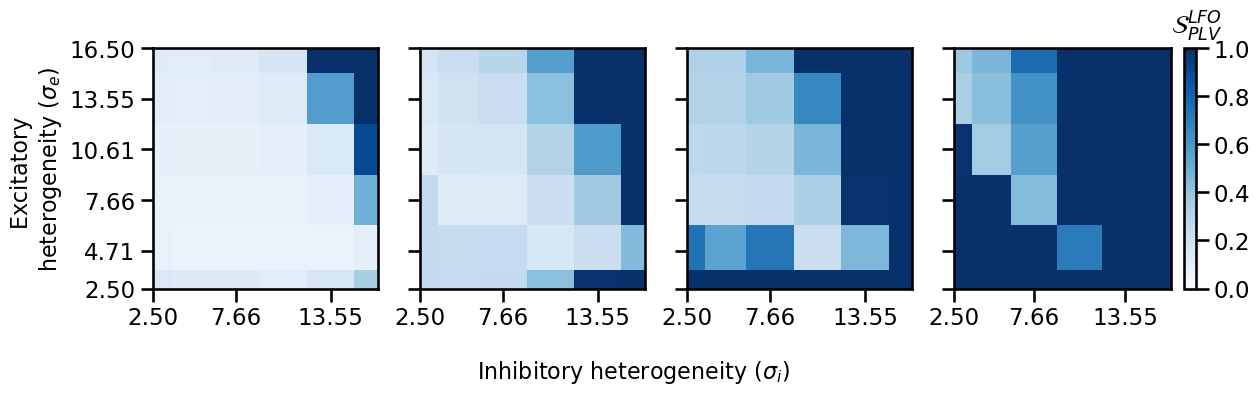

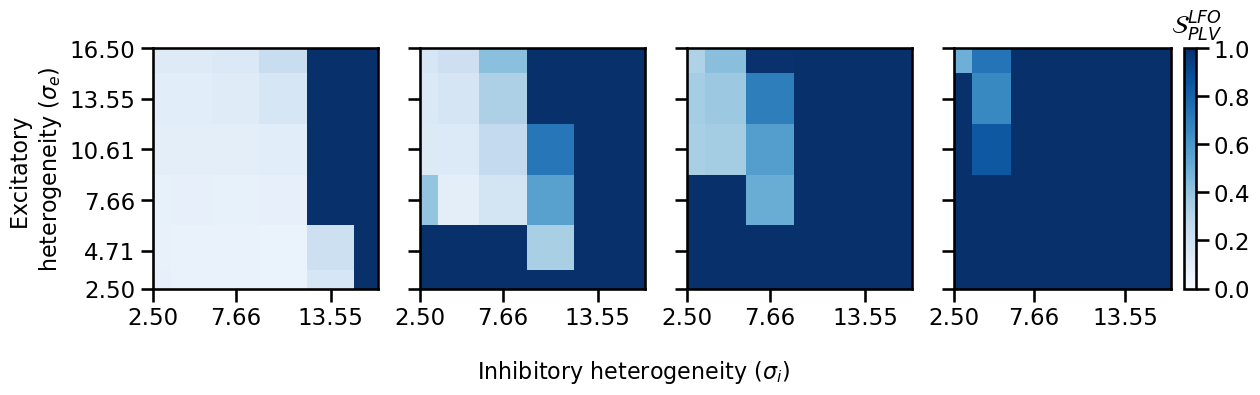

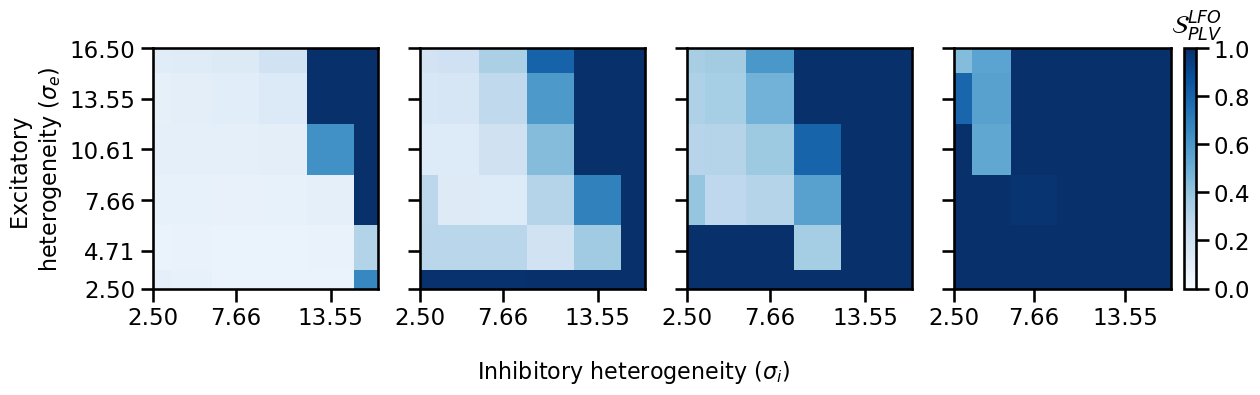

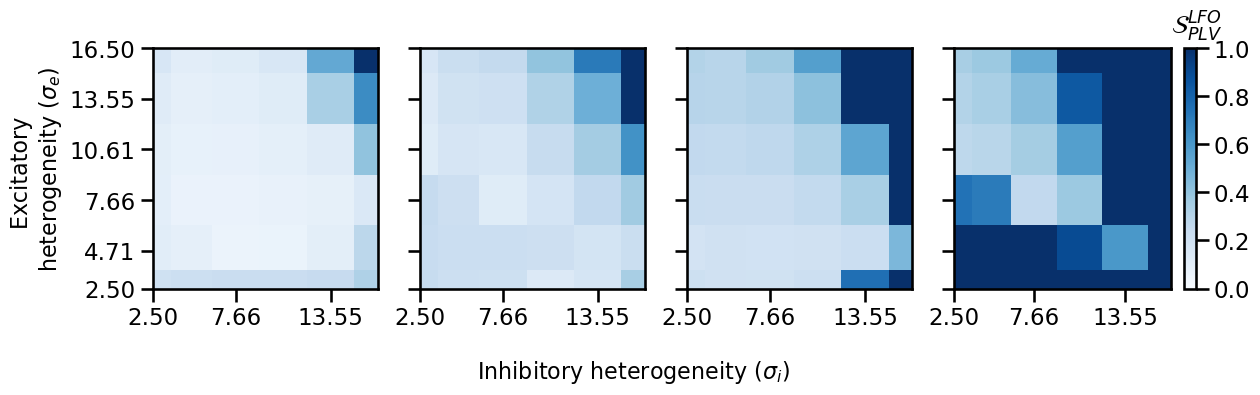

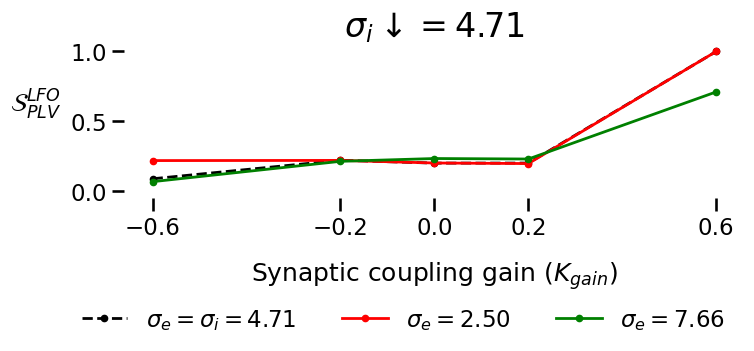

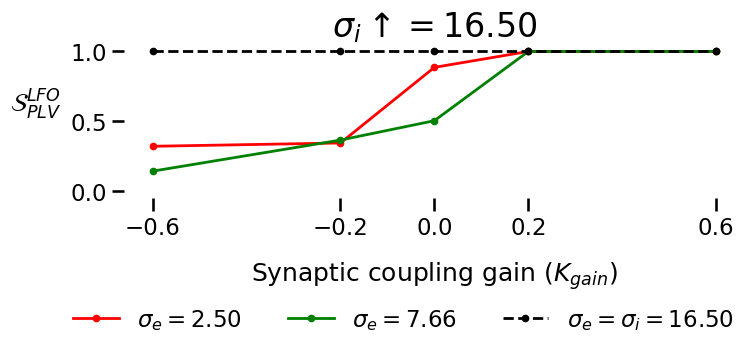

In [18]:
measure = "PLV"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{PLV}^{LFO}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="LFO", saveroot=figureroot)

### Synchronization in HFOs

In [19]:
load_dir = "../system_02/results/synchron/"
load_str = datetime.datetime(2024, 4, 24)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, 'results*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 25


In [20]:
# Sorting the files

iVals = {}
kVals = {}

for path in file_paths:
    baseName = os.path.basename(path).split('mV.pkl')[0]
    I = float(baseName.split('_')[-1])
    K = float(baseName.split('_')[2])

    if I not in iVals.keys():
        iVals[I] = []
        kVals[I] = []

    iVals[I].append(path)
    kVals[I].append(K)

for I, kVals_arr in kVals.items():
    kVals_arr = np.array(kVals_arr)
    kSort = np.argsort(kVals_arr) 
    iVals[I] = np.array(iVals[I])[kSort]

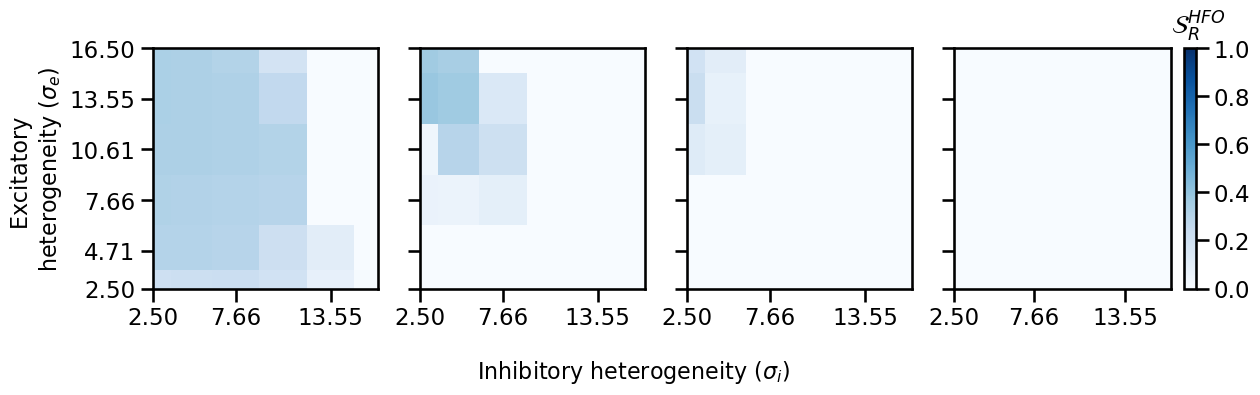

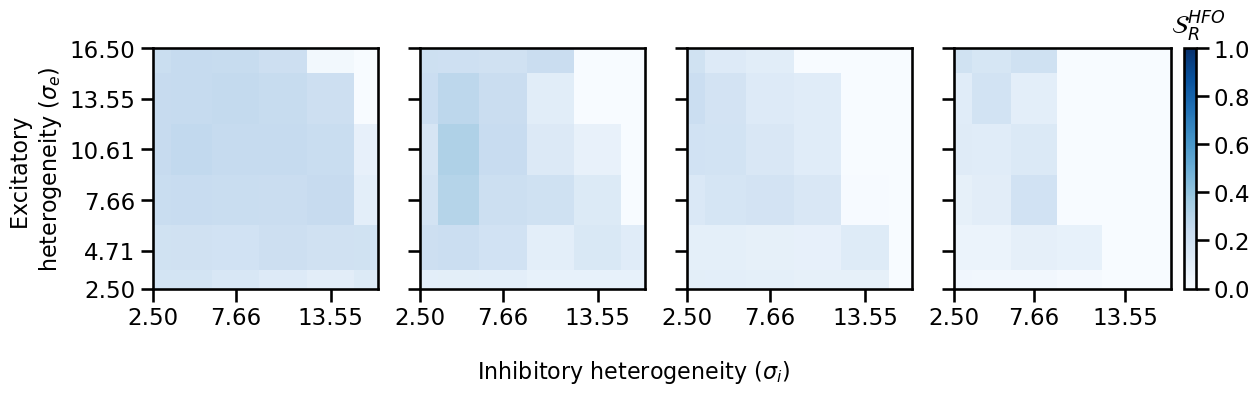

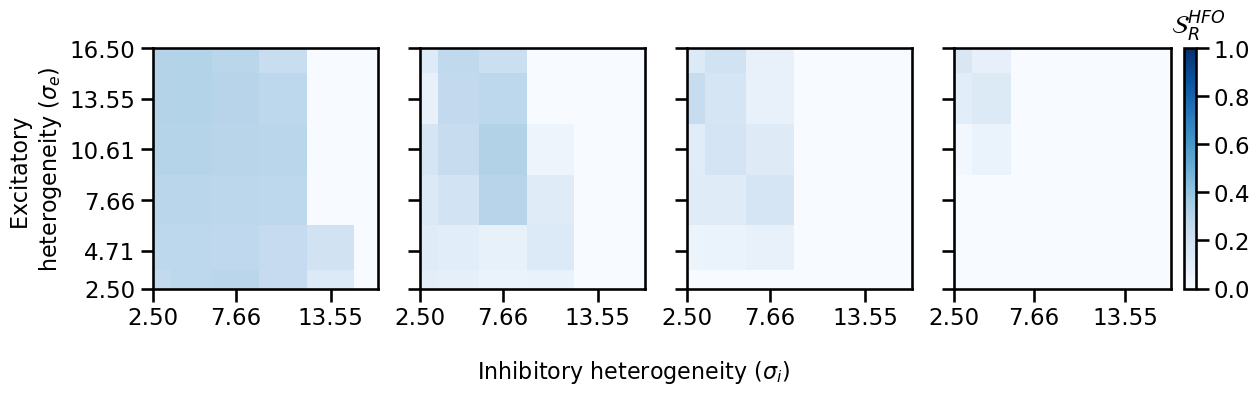

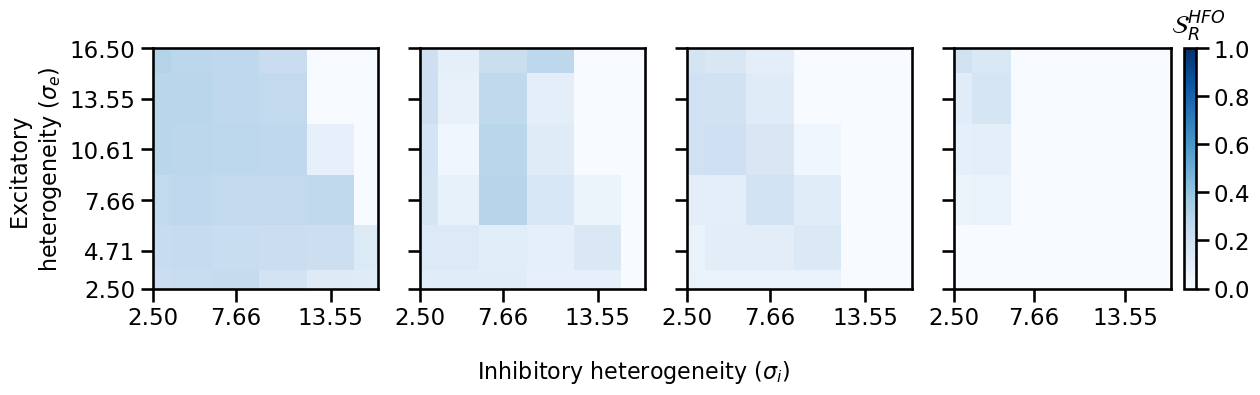

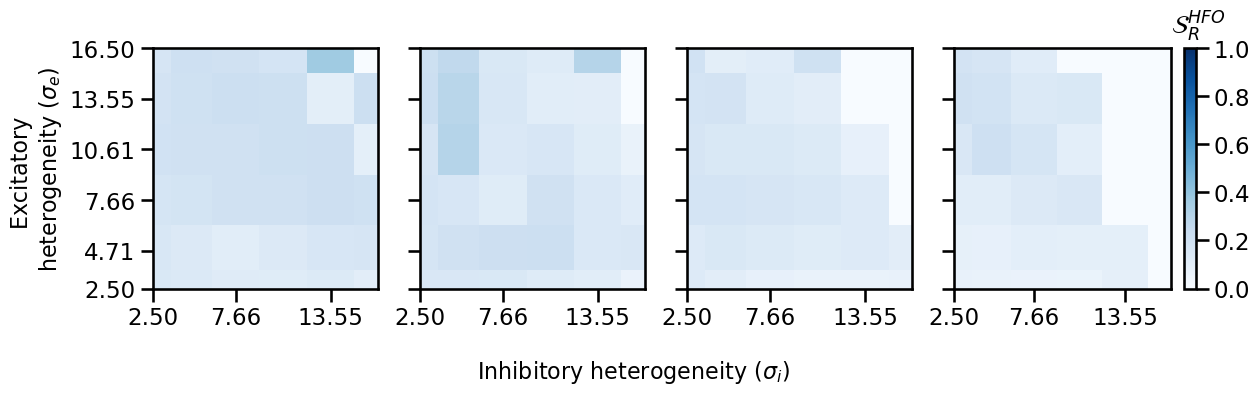

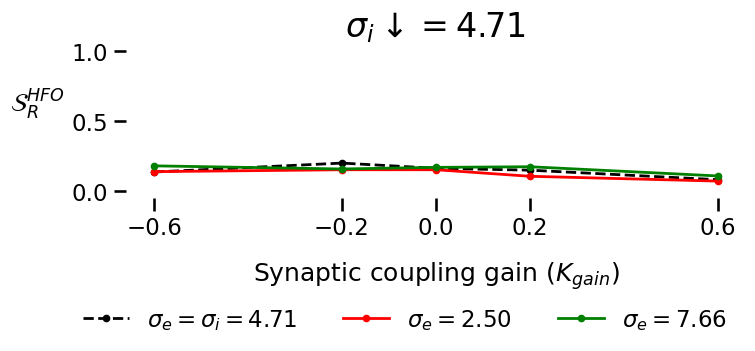

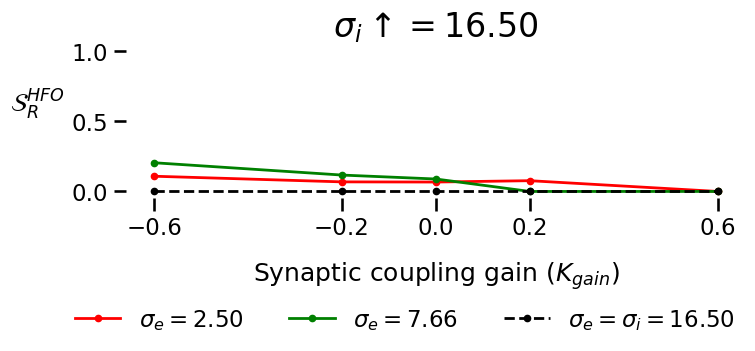

In [21]:
measure = "GlobalSync"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{R}^{HFO}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="HFO", saveroot=figureroot)

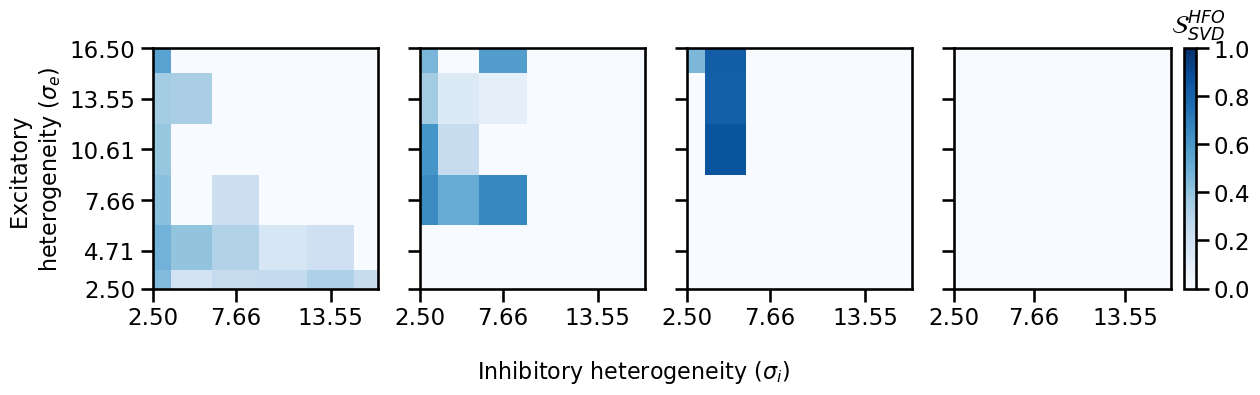

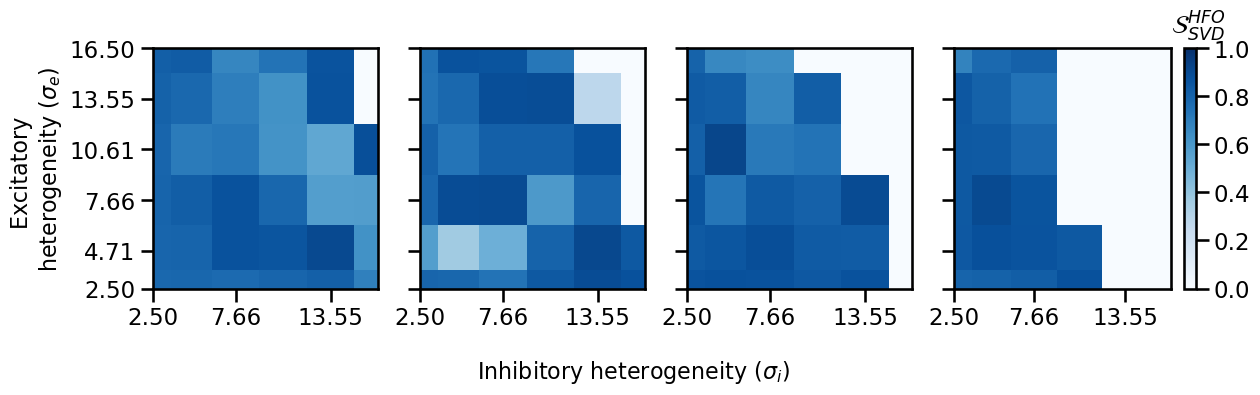

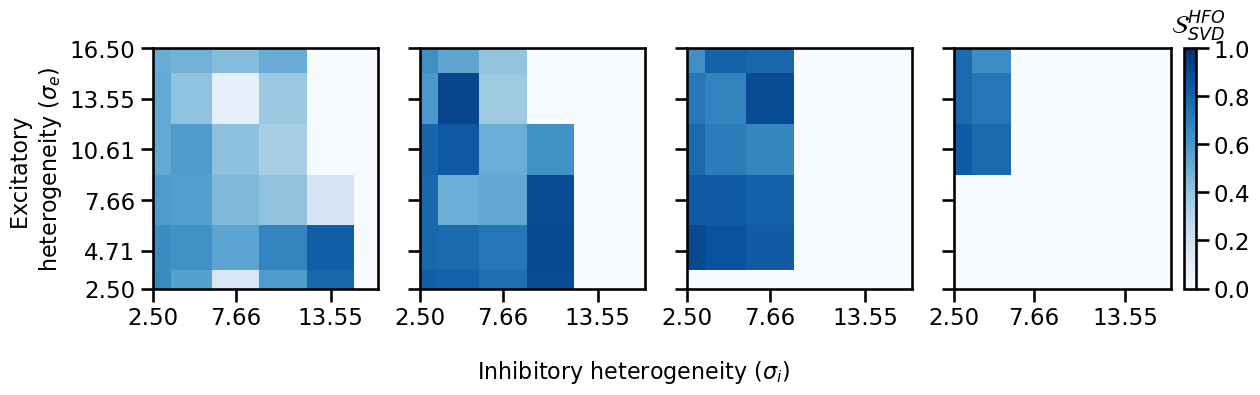

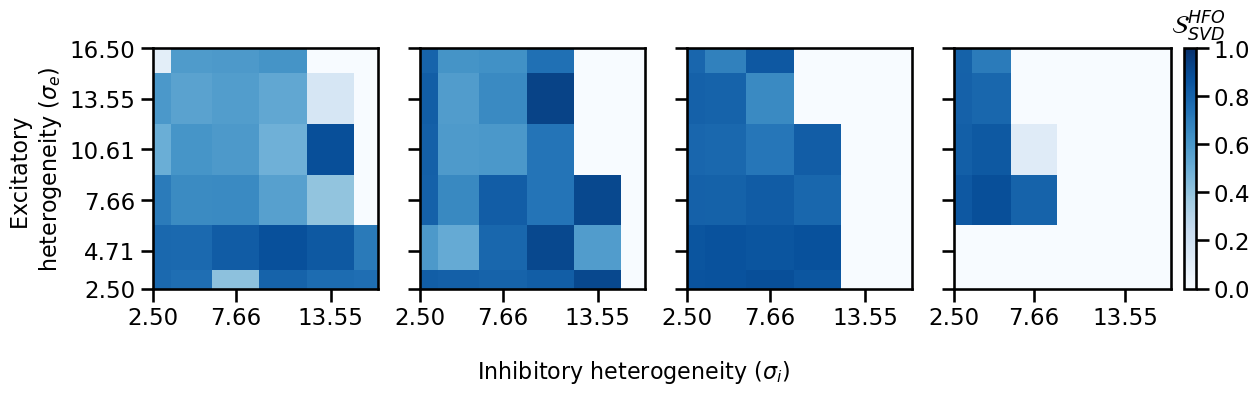

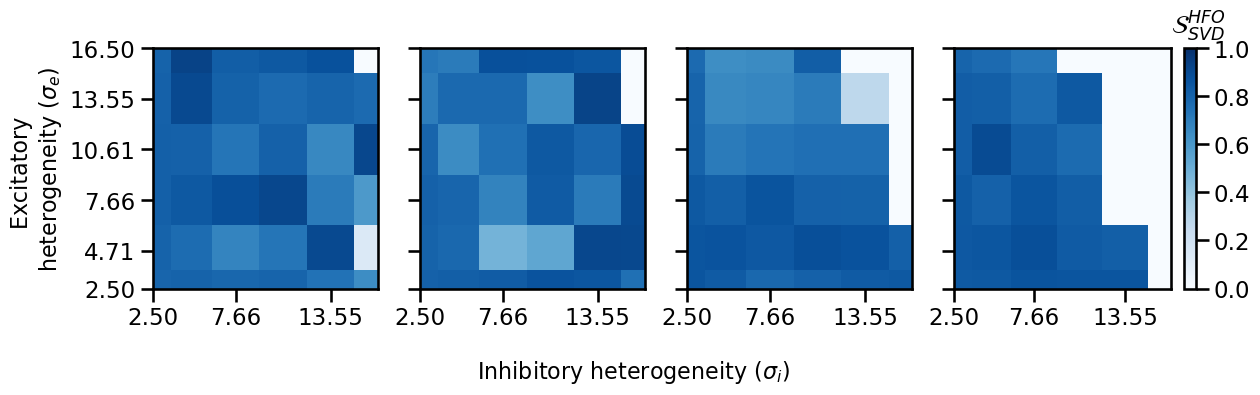

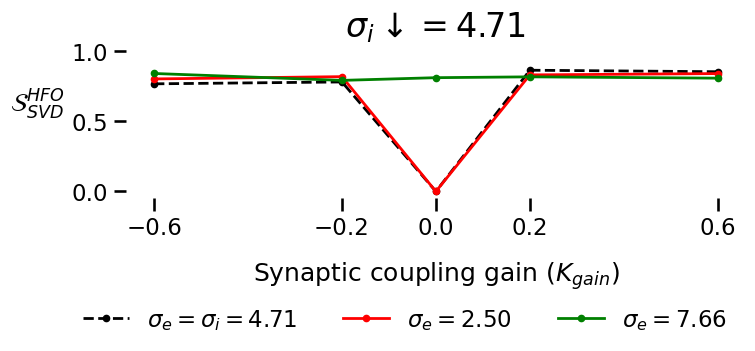

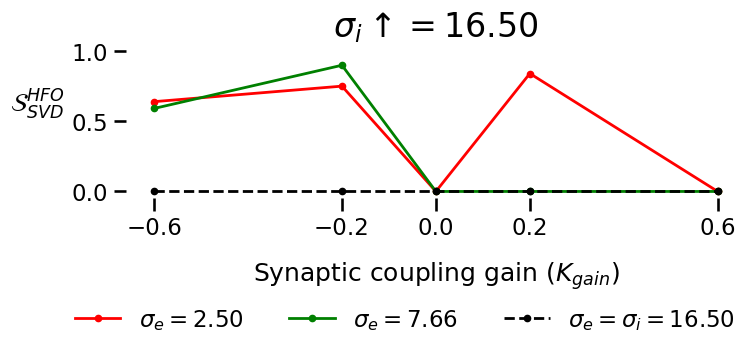

In [22]:
measure = "SVD"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{SVD}^{HFO}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="HFO", saveroot=figureroot)

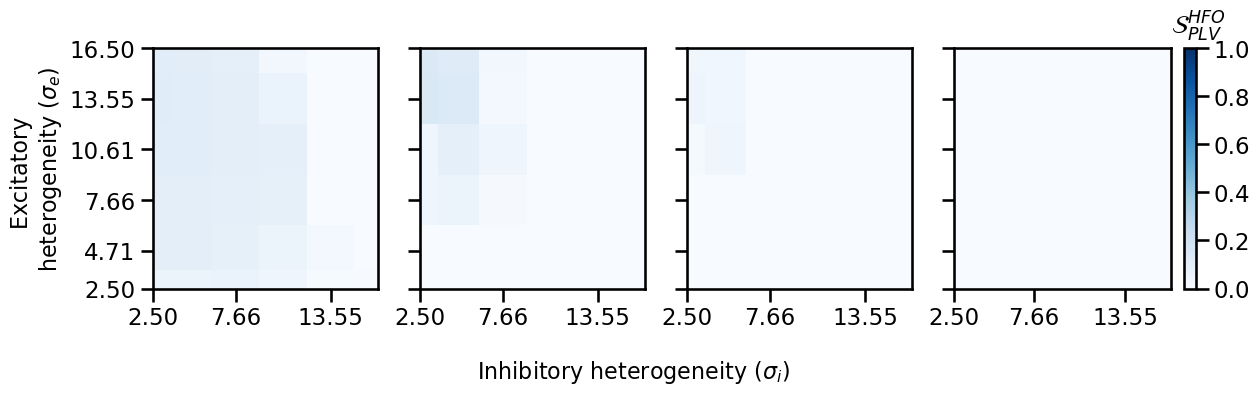

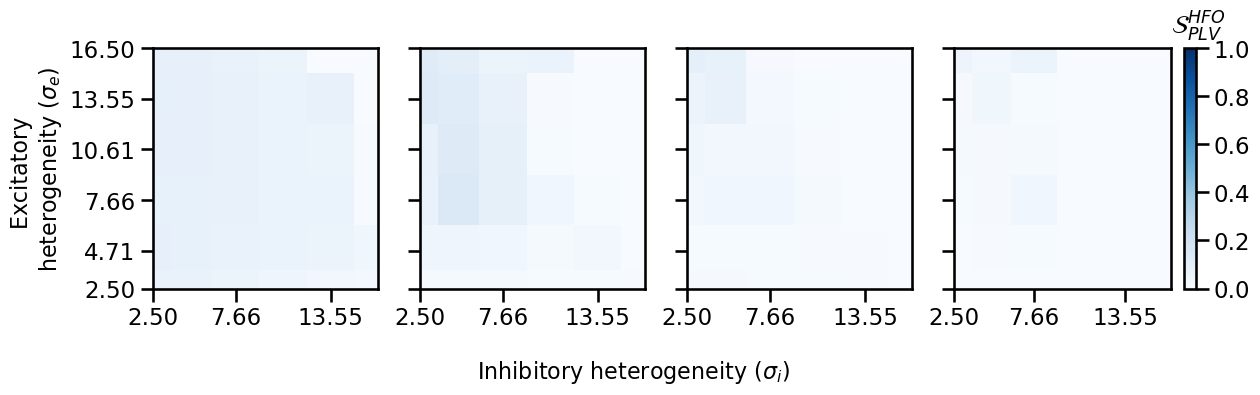

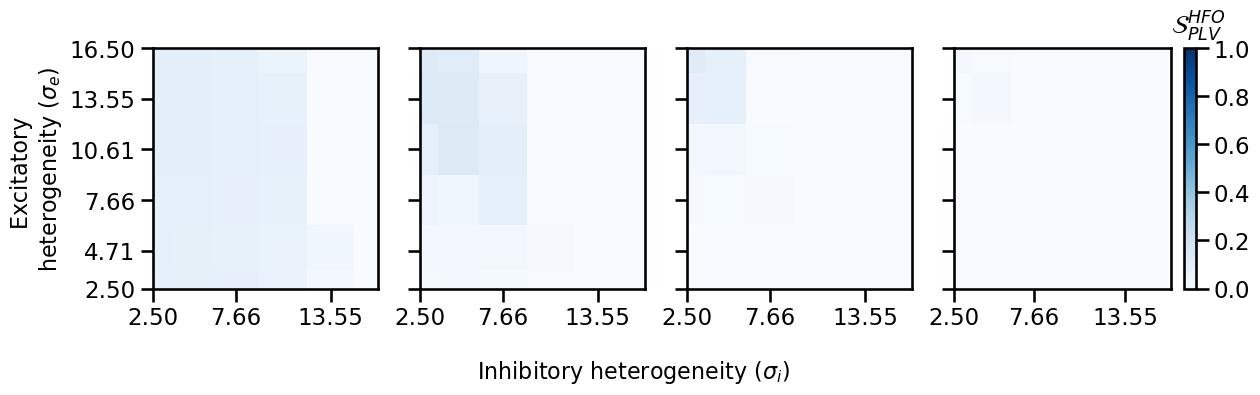

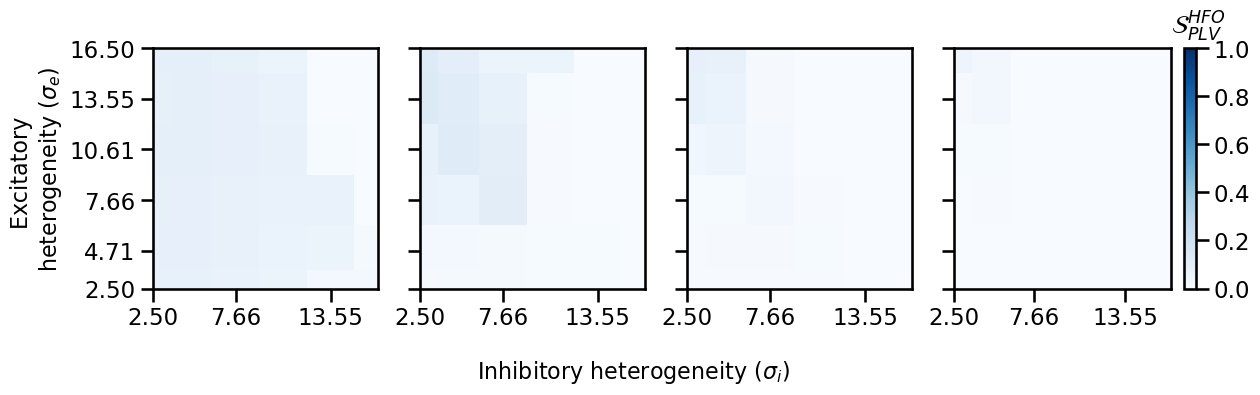

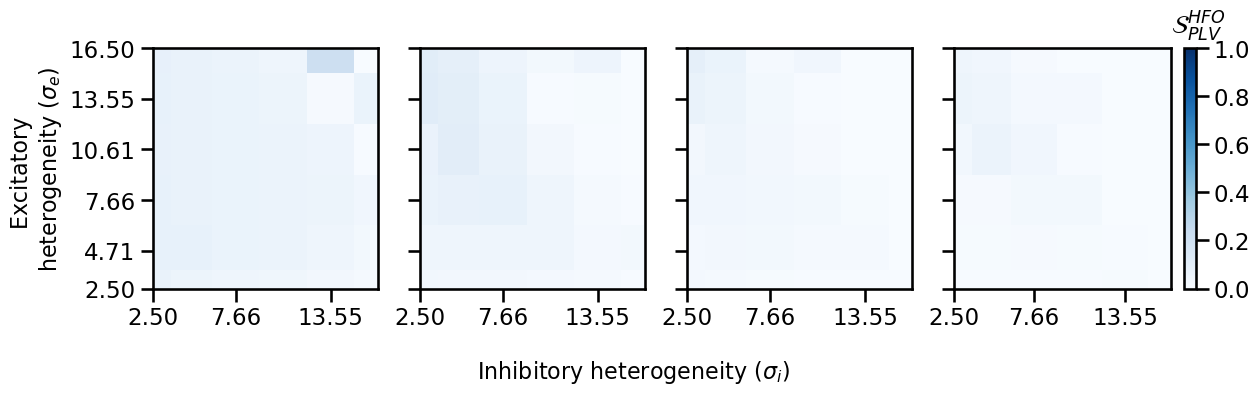

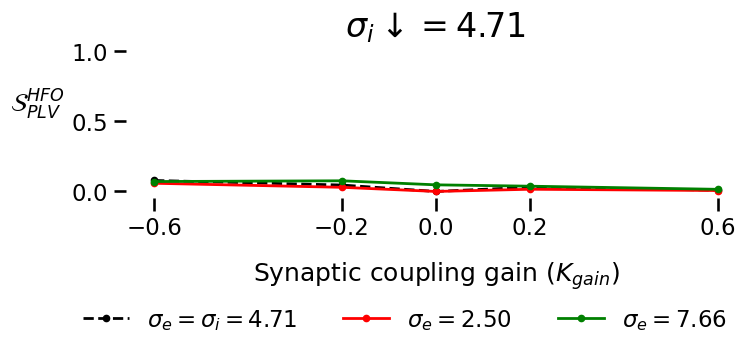

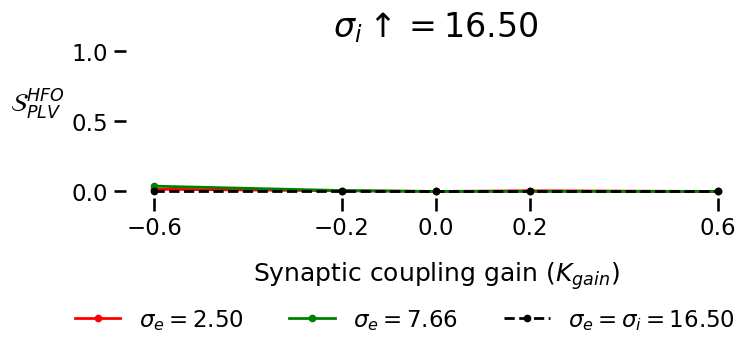

In [23]:
measure = "PLV"

PlotResponses(Imod = iPert, measure = measure, mSymbol = r"$\mathcal{S}_{PLV}^{HFO}$", xArr = eval_sigmai, yArr = eval_sigmae, kArr=kValArr, freqBand="HFO", saveroot=figureroot)

In [24]:
# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

# setting init values
np.random.seed(0)
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

t_start = 1000
t_end = params['T']

In [25]:
center_freq=12.
fs=1000

freq_arr = np.linspace(1, fs / 2, 2000)
widths = center_freq * fs / (2 * freq_arr * np.pi)

In [26]:
params['i_e1'] = 0.5 / params['gamma'] + params['i_e2']
seVals = np.array([eval_sigmae[0], eval_sigmae[2]])
siVals = np.array([eval_sigmae[1], eval_sigmae[-1]])

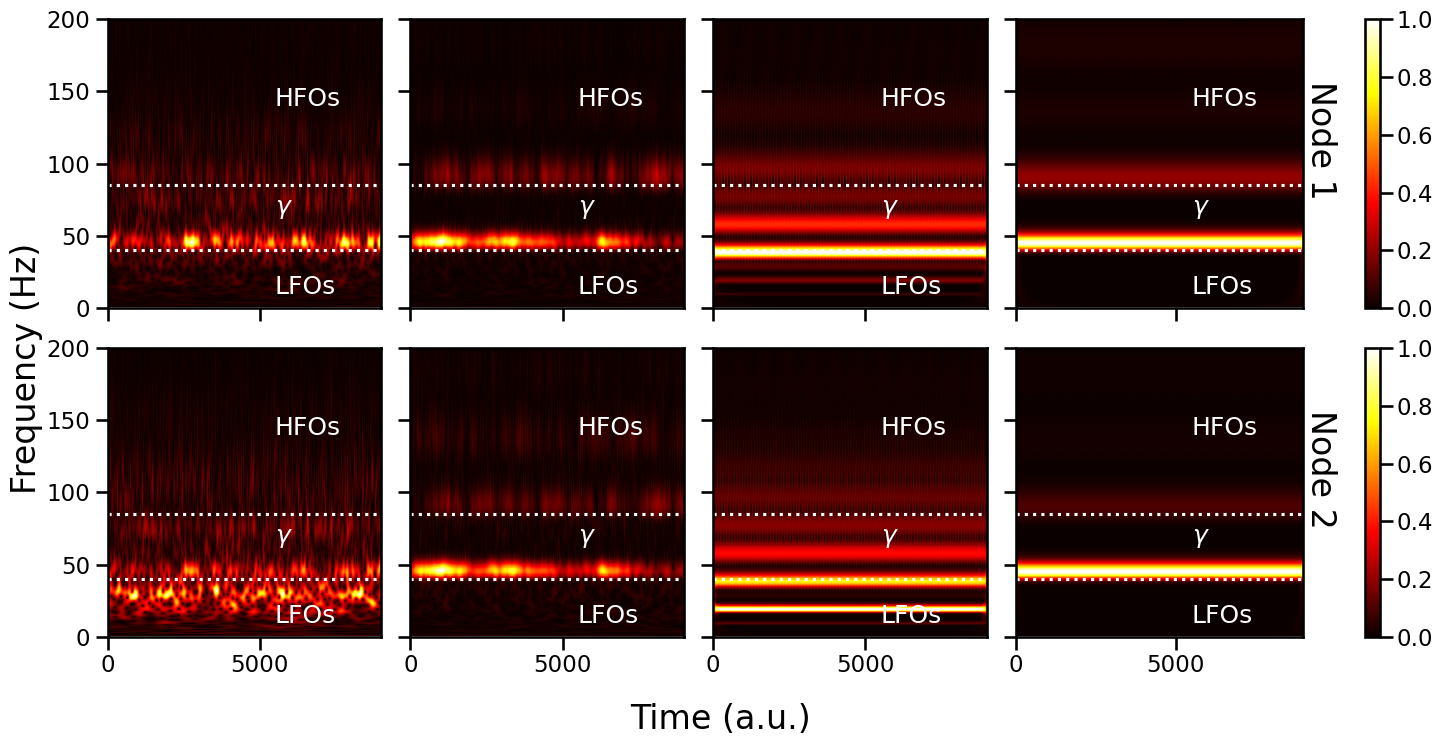

In [27]:
params['K'] = -0.6

fig, axes = plt.subplots(2, 4, figsize=(14.8, 7.5), sharex=True, sharey=True, gridspec_kw={'width_ratios':[1, 1, 1, 1.5]})
nCol = 0

for nSi, Si in enumerate(siVals):
    params['sig_i1'] = params['sig_i2'] = Si
    for nSe, Se in enumerate(seVals):
        params['sig_e1'] = params['sig_e2'] = Se

        u = np.zeros((n_trials, 4, T))
        u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

        ue1 = np.mean(u[:, 0, :], axis=0)
        ue2 = np.mean(u[:, 2, :], axis=0)

        wtmatr1 = signal.cwt(ue1[t_start:t_end] - np.mean(ue1[t_start:t_end]), signal.morlet2, widths, w=center_freq)
        wtmatr2 = signal.cwt(ue2[t_start:t_end] - np.mean(ue2[t_start:t_end]), signal.morlet2, widths, w=center_freq)

        pcs1 = axes[0, nCol].pcolormesh(time_[:-t_start], freq_arr, np.abs(wtmatr1) / np.max(np.abs(wtmatr1)+0.0001), cmap='hot', vmin=0, vmax=1)
        axes[0, nCol].set_ylim(0, 200)
        axes[0, nCol].axhline(y=40, color='w', linestyle=":")
        axes[0, nCol].axhline(y=85, color='w', linestyle=":")
        axes[0, nCol].text(5500, 10, "LFOs", color='w', fontsize=18)
        axes[0, nCol].text(5500, 140, "HFOs", color='w', fontsize=18)
        axes[0, nCol].text(5505, 65, r"$\gamma$", color='w', fontsize=18)

        pcs2 = axes[1, nCol].pcolormesh(time_[:-t_start], freq_arr, np.abs(wtmatr2) / np.max(np.abs(wtmatr2)+0.0001), cmap='hot', vmin=0, vmax=1)
        axes[1, nCol].set_ylim(0, 200)
        axes[1, nCol].axhline(y=40, color='w', linestyle=":")
        axes[1, nCol].axhline(y=85, color='w', linestyle=":")
        axes[1, nCol].text(5500, 10, "LFOs", color='w', fontsize=18)
        axes[1, nCol].text(5500, 140, "HFOs", color='w', fontsize=18)
        axes[1, nCol].text(5505, 65, r"$\gamma$", color='w', fontsize=18)

        if nCol == 3:
            axes[0, nCol].text(9010, 80, "Node 1", rotation=270, fontsize=24)
            axes[1, nCol].text(9010, 80, "Node 2", rotation=270, fontsize=24)
            cbar1 = fig.colorbar(pcs1, ax=axes[0, nCol], location='right', pad=.15)
            cbar2 = fig.colorbar(pcs2, ax=axes[1, nCol], location='right', pad=.15)
        
        nCol += 1

fig.supylabel("Frequency (Hz)", fontsize=24)
fig.supxlabel("Time (a.u.)", fontsize=24)
plt.tight_layout()
plt.show()

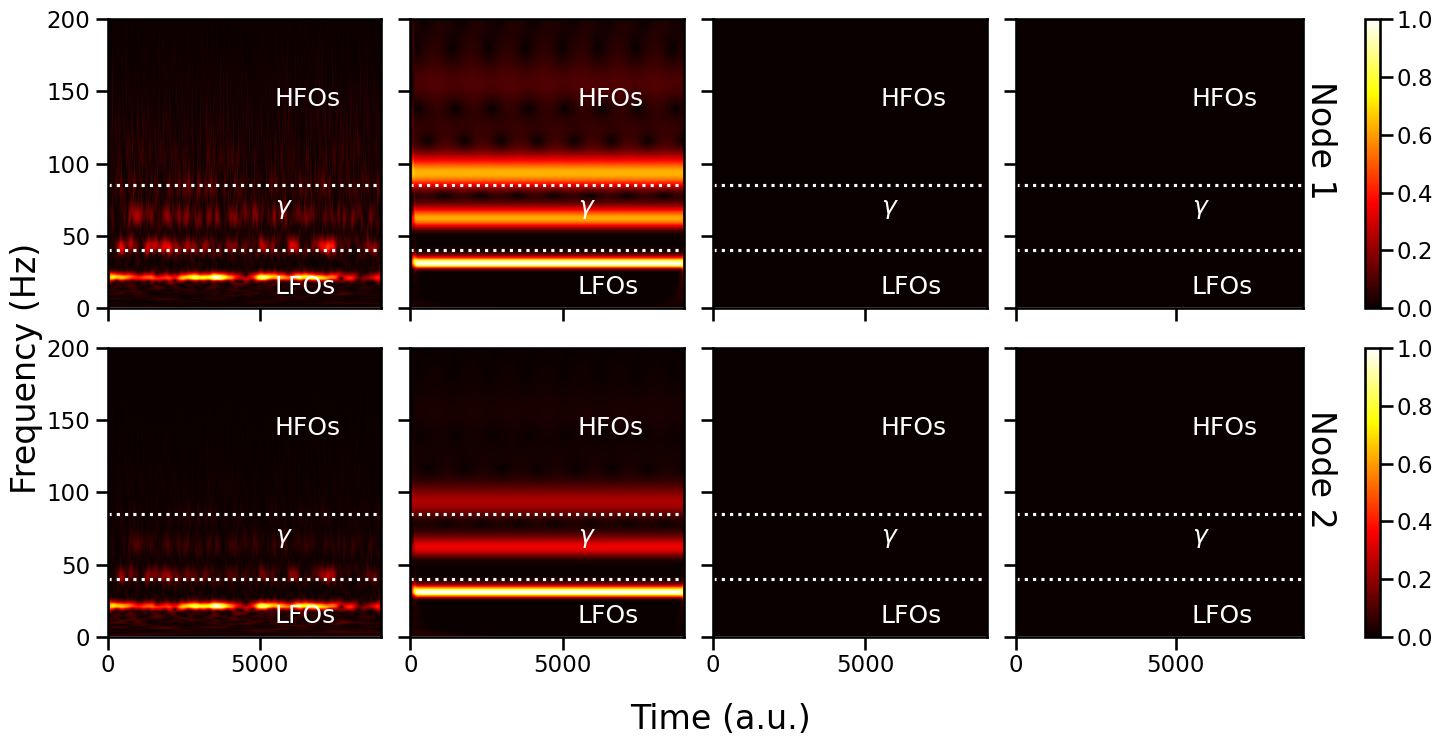

In [28]:
params['K'] = 0.6

fig, axes = plt.subplots(2, 4, figsize=(14.8, 7.5), sharex=True, sharey=True, gridspec_kw={'width_ratios':[1, 1, 1, 1.5]})
nCol = 0

for nSi, Si in enumerate(siVals):
    params['sig_i1'] = params['sig_i2'] = Si
    for nSe, Se in enumerate(seVals):
        params['sig_e1'] = params['sig_e2'] = Se

        u = np.zeros((n_trials, 4, T))
        u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

        ue1 = np.mean(u[:, 0, :], axis=0)
        ue2 = np.mean(u[:, 2, :], axis=0)

        wtmatr1 = signal.cwt(ue1[t_start:t_end] - np.mean(ue1[t_start:t_end]), signal.morlet2, widths, w=center_freq)
        wtmatr2 = signal.cwt(ue2[t_start:t_end] - np.mean(ue2[t_start:t_end]), signal.morlet2, widths, w=center_freq)

        pcs1 = axes[0, nCol].pcolormesh(time_[:-t_start], freq_arr, np.abs(wtmatr1) / np.max(np.abs(wtmatr1)+0.0001), cmap='hot', vmin=0, vmax=1)
        axes[0, nCol].set_ylim(0, 200)
        axes[0, nCol].axhline(y=40, color='w', linestyle=":")
        axes[0, nCol].axhline(y=85, color='w', linestyle=":")
        axes[0, nCol].text(5500, 10, "LFOs", color='w', fontsize=18)
        axes[0, nCol].text(5500, 140, "HFOs", color='w', fontsize=18)
        axes[0, nCol].text(5505, 65, r"$\gamma$", color='w', fontsize=18)

        pcs2 = axes[1, nCol].pcolormesh(time_[:-t_start], freq_arr, np.abs(wtmatr2) / np.max(np.abs(wtmatr2)+0.0001), cmap='hot', vmin=0, vmax=1)
        axes[1, nCol].set_ylim(0, 200)
        axes[1, nCol].axhline(y=40, color='w', linestyle=":")
        axes[1, nCol].axhline(y=85, color='w', linestyle=":")
        axes[1, nCol].text(5500, 10, "LFOs", color='w', fontsize=18)
        axes[1, nCol].text(5500, 140, "HFOs", color='w', fontsize=18)
        axes[1, nCol].text(5505, 65, r"$\gamma$", color='w', fontsize=18)

        if nCol == 3:
            axes[0, nCol].text(9010, 80, "Node 1", rotation=270, fontsize=24)
            axes[1, nCol].text(9010, 80, "Node 2", rotation=270, fontsize=24)
            cbar1 = fig.colorbar(pcs1, ax=axes[0, nCol], location='right', pad=.15)
            cbar2 = fig.colorbar(pcs2, ax=axes[1, nCol], location='right', pad=.15)
        
        nCol += 1

fig.supylabel("Frequency (Hz)", fontsize=24)
fig.supxlabel("Time (a.u.)", fontsize=24)
plt.tight_layout()
plt.show()